<a href="https://colab.research.google.com/github/jawdatmerhy/public/blob/main/softwareRisk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [197]:
# importing essential libraries
# Install Keras Tuner
#!pip install keras-tuner
#!pip install -U sdv

#from ctgan import CTGAN

from re import X
import pandas as pd
import missingno as msno
from IPython.display import display, HTML
from io import StringIO
from termcolor import colored # For colored text printing
from tabulate import tabulate
from scipy.stats import chi2_contingency
from prettytable import PrettyTable
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats.mstats import winsorize
import warnings
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neural_network import MLPClassifier
from sklearn.utils import class_weight
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, accuracy_score, roc_curve, auc , roc_auc_score
from sklearn.metrics import recall_score, confusion_matrix, precision_score, f1_score, accuracy_score, classification_report
import plotly.express as px
import plotly.graph_objects as go
from pandas.plotting import parallel_coordinates
import warnings
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
import time
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification
import time

warnings.filterwarnings("ignore")

def display_colored_message(message, color='black', background='yellow'):
    display(HTML(f'<span style="color: {color}; background-color: {background};">{message}</span>'))

def display_colored_sub_message(message):
     print("\033[1;33;44m" + message + "\033[0m")

def display_colored_title_message(message):
    print(f"\033[1m\033[34m{'='*40}\n" + message)
    print(f"{'='*40}\033[0m")

display_colored_message("THE REQUIRED LIBRARIES WERE SUCCESSFULLY IMPORTED...")

####################################################
try:
    # Read the CSV file and save it in "risk_data" variable
    # reading csv file
    path = '/content/sample_data/'
    df = pd.read_csv(path + 'data.csv')

    # Print a success message
    display_colored_message("THE DATASET LOADED SUCCESSFULLY...")

except FileNotFoundError:
    # Handle file not found error
    print(colored("ERROR: File not found!", "red", attrs=['reverse']))

except Exception as e:
    # Handle other exceptions
    print(colored(f"ERROR: {e}", "red", attrs=['reverse']))

In [198]:
####################################################
display_colored_message("PRINTING THE FIRST FIVE ROWS OF THE DATASET...")
# printing first five rows of dataset

print(colored(tabulate(df.head(5), headers='keys', tablefmt='fancy_grid'), 'cyan'))

####################################################
display_colored_message("PRINTING THE LAST FIVE ROWS OF THE DATASET...")
# Printing last five rows of datset
print(colored(tabulate(df.tail(5), headers='keys', tablefmt='fancy_grid'), 'cyan'))


╒════╤══════════════════════════════╤══════════════════════════╤═════════════╤══════════════════════╤══════════════╤════════════════╤═════════════════╤═════════════════════════╤═══════════════════════╤════════════════════╤════════════════╤══════════════════════╤═══════════════════╤══════════════╤══════════════╤═══════════════════════╤════════════════════╤═════════════════╤══════════════════════════╤════════════════╤═══════════════════╤════════════════╤═════════════╤═══════════════╤════════════════════╤════════════════════════════════╤═════════════════╤═══════════════════════════╤═══════════════════════╤══════════╕
│    │ Timestamp                    │ Name                     │ Region      │ Job                  │   Experience │ Company Type   │ Project Scope   │ Requirement Clearness   │ Requirement Changes   │ Project Planning   │ Project Size   │ Project Management   │ Communication     │ Cost         │ Commitment   │ Modern Technologies   │ Responsibilities   │ Skilled Staff   │ Or

╒════╤══════════════════════════════╤═══════════════╤═════════════╤══════════════════════╤══════════════╤════════════════╤═════════════════╤═════════════════════════╤═══════════════════════╤════════════════════╤════════════════╤══════════════════════╤═══════════════════╤══════════╤══════════════╤═══════════════════════╤════════════════════╤═════════════════╤══════════════════════════╤════════════════╤═══════════════════╤════════════════╤═════════════╤════════════════╤════════════════════════╤════════════════════════════════╤═════════════════════╤═══════════════════════════╤═══════════════════════╤══════════╕
│    │ Timestamp                    │ Name          │ Region      │ Job                  │   Experience │ Company Type   │ Project Scope   │ Requirement Clearness   │ Requirement Changes   │ Project Planning   │ Project Size   │ Project Management   │ Communication     │ Cost     │ Commitment   │ Modern Technologies   │ Responsibilities   │ Skilled Staff   │ Organization Stability 

In [199]:
####################################################
display_colored_message("OBTAINING THE DIMENSIONS OF THE DATASET...")
# Obtaining the dimensions of dataset
print("The shape =", df.shape)

# Dataset dimensions and statistics
num_rows, num_cols = df.shape
num_features = num_cols - 1
num_data = num_rows * num_cols

# Print the information about the dataset
print(f"Number of Rows: {num_rows}")
print(f"Number of Columns: {num_cols}")
print(f"Number of Features: {num_features}")
print(f"Number of All Data: {num_data}")


The shape = (90, 30)
Number of Rows: 90
Number of Columns: 30
Number of Features: 29
Number of All Data: 2700


In [200]:
####################################################
display_colored_message("DISPLAY THE LIST COLUMNS...")
print(df.columns)

Index(['Timestamp', 'Name', 'Region', 'Job', 'Experience', 'Company Type',
       'Project Scope', 'Requirement Clearness', 'Requirement Changes',
       'Project Planning', 'Project Size', 'Project Management',
       'Communication', 'Cost', 'Commitment', 'Modern Technologies',
       'Responsibilities', 'Skilled Staff', 'Organization Stability',
       'Cultural', 'Time Difference', 'Progress', 'Team Size', 'Methodology',
       'Project Schedule', 'Resource Estimation Accuracy', 'Scope Changes',
       'Incomplete Requirements', 'Customer Commitment', 'Status'],
      dtype='object')


In [201]:
####################################################
display_colored_message("RENAME COLUMNS...")

def rename_columns(df):
    # Rename columns in a single call
    df = df.rename(columns={
        'Company Type': 'CompanyType',
        'Requirement clearness': 'RequirementClearness',
        'Project Scope': 'ProjectScope',
        'Project Planning': 'ProjectPlanning',
        'Requirement Clearness': 'RequirementClearness',
        'Requirement Changes': 'RequirementChanges',
        'Project Size': 'ProjectSize',
        'Project Management': 'ProjectManagement',
        'Modern Technologies': 'ModernTechnologies',
        'Skilled Staff': 'SkilledStaff',
        'Organization Stability': 'OrganizationStability',
        'Time Difference': 'TimeDifference',
        'Team Size': 'TeamSize',
        'Project Schedule' : 'ProjectSchedule',
        'Resource Estimation Accuracy': 'ResourceEstimationAccuracy',
        'Scope Changes': 'ScopeChanges',
        'Incomplete Requirements': 'IncompleteRequirements',
        'Customer Commitment' : 'CustomerCommitment'
    })
    return df

#RENAME COLUMNS
df = rename_columns(df)

print(df.columns)

Index(['Timestamp', 'Name', 'Region', 'Job', 'Experience', 'CompanyType',
       'ProjectScope', 'RequirementClearness', 'RequirementChanges',
       'ProjectPlanning', 'ProjectSize', 'ProjectManagement', 'Communication',
       'Cost', 'Commitment', 'ModernTechnologies', 'Responsibilities',
       'SkilledStaff', 'OrganizationStability', 'Cultural', 'TimeDifference',
       'Progress', 'TeamSize', 'Methodology', 'ProjectSchedule',
       'ResourceEstimationAccuracy', 'ScopeChanges', 'IncompleteRequirements',
       'CustomerCommitment', 'Status'],
      dtype='object')


In [202]:
####################################################
display_colored_message("STATISTICAL SUMMARY OF THE DATASET...")
# Statistical summary of dataset
#df.info()

# Function to extract info into a DataFrame
def extract_info(df):
    buffer = StringIO()
    df.info(buf=buffer)
    s = buffer.getvalue()

    # Parse the buffer content to extract column info
    lines = s.split('\n')
    col_lines = lines[5:-3]  # Data lines

    memory_line = lines[-2]  # Memory usage line

    info_dict = {
        "Column": [],
        "Non-Null Count": [],
        "Dtype": []
    }

    for line in col_lines:
        parts = line.split()
        info_dict["Column"].append(parts[1])
        info_dict["Non-Null Count"].append(int(parts[2].replace(',', '')))
        info_dict["Dtype"].append(parts[-1])

    info_df = pd.DataFrame(info_dict)
    return info_df

# Extract info and create a DataFrame
info_df = extract_info(df)

# Convert Non-Null Count to a proportion for better gradient visualization
info_df['Non-Null Proportion'] = info_df['Non-Null Count'] / len(df)

# Style the DataFrame
styled_info_df = info_df.style.background_gradient(cmap='viridis', subset=['Non-Null Proportion'])

# Display the styled DataFrame
display(styled_info_df)

,Column,Non-Null Count,Dtype,Non-Null Proportion
0,Timestamp,90,object,1.000000
1,Name,84,object,0.933333
2,Region,90,object,1.000000
3,Job,90,object,1.000000
4,Experience,90,int64,1.000000
5,CompanyType,90,object,1.000000
6,ProjectScope,90,object,1.000000
7,RequirementClearness,90,object,1.000000
8,RequirementChanges,90,object,1.000000
9,ProjectPlanning,90,object,1.000000


In [203]:
####################################################
display_colored_message("SUMMARY STATISTICTS FOR NUMERICAL COLUMNS...")
#Calculate summary statistics for numerical columns using describe()
#print(df.describe())

# Describe and style
styled_df = df.describe().T.style.background_gradient(cmap='viridis')

# Use display to explicitly show the styled DataFrame
display(styled_df)

,count,mean,std,min,25%,50%,75%,max
Experience,90.000000,9.766667,7.259322,1.000000,4.000000,8.000000,15.000000,40.000000
TeamSize,90.000000,6.711111,6.873241,0.000000,3.000000,5.000000,8.750000,50.000000
Status,90.000000,0.822222,0.384467,0.000000,1.000000,1.000000,1.000000,1.000000


In [204]:
####################################################
display_colored_message("TOTAL OF NULL VALUES...")
# Calculate the total of null values
print(df.isnull().sum().sum())
print('\nColumns missing values: ')
print(df.isnull().sum())

79

Columns missing values: 
Timestamp                      0
Name                           6
Region                         0
Job                            0
Experience                     0
CompanyType                    0
ProjectScope                   0
RequirementClearness           0
RequirementChanges             0
ProjectPlanning                0
ProjectSize                    0
ProjectManagement              3
Communication                  0
Cost                           0
Commitment                     0
ModernTechnologies             0
Responsibilities               0
SkilledStaff                   0
OrganizationStability          0
Cultural                       0
TimeDifference                 0
Progress                       0
TeamSize                       0
Methodology                    0
ProjectSchedule               14
ResourceEstimationAccuracy    14
ScopeChanges                  14
IncompleteRequirements        14
CustomerCommitment            14
Status        

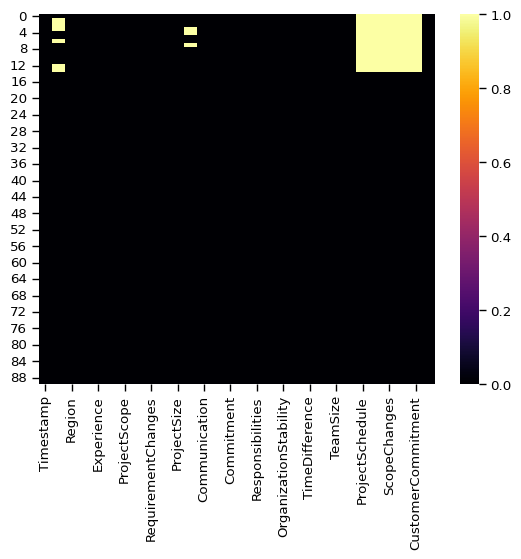

In [205]:
####################################################
display_colored_message("\nVISULIZE THE NULL VALUES USING HEATMAP...")
# Visulize the null values using heatmp
df.isnull().sum()
sns.heatmap(df.isnull(), cbar=True, cmap='inferno')
plt.show()

In [206]:
####################################################
display_colored_message("FIND THE DUPLICATED ROWS...")

def duplicated_rows(df):
    #Find the duplicated rows
    print('Duplicated row sum : ', df.duplicated().sum())

    display_colored_sub_message("\n>>>>>>>>>>>>>> To remove duplicated lines if they exist")
    print("Calculate the percentage of duplicated rows")
    # Calculate the percentage of duplicated rows
    percent_duplication = df.duplicated().sum() / df.shape[0]
    print(f"Percentage of duplicated rows: {percent_duplication * 100:.2f}%")

    display_colored_sub_message("\n>>>>>>>>>>>>>> Check if there are any duplicated rows and if the percentage is less than 5%")
    # Check if there are any duplicated rows and if the percentage is less than 5%
    if 0 < percent_duplication < 0.05:
        display_colored_sub_message("\n>>>>>>>>>>>>>> Drop duplicated rows")
        # Drop duplicated rows
        df = df.drop_duplicates()
    else:
        print("There are no duplicated rows or the percentage is 5% or higher")

    # Optional: print the percentage of duplication
    print(f"Percentage of duplicated rows: {percent_duplication * 100:.2f}%")


    fig = go.Figure(go.Indicator(
        mode = "gauge+number",
        gauge = {
          'axis': {'range': [None, 100]}},
        value = percent_duplication,
        title = {'text': "Duplication %"},
        domain = {'x': [0, 1], 'y': [0, 1]}
    ))
    fig.show()

duplicated_rows(df)

Duplicated row sum :  0

>>>>>>>>>>>>>> To remove duplicated lines if they exist
Calculate the percentage of duplicated rows
Percentage of duplicated rows: 0.00%

>>>>>>>>>>>>>> Check if there are any duplicated rows and if the percentage is less than 5%
There are no duplicated rows or the percentage is 5% or higher
Percentage of duplicated rows: 0.00%


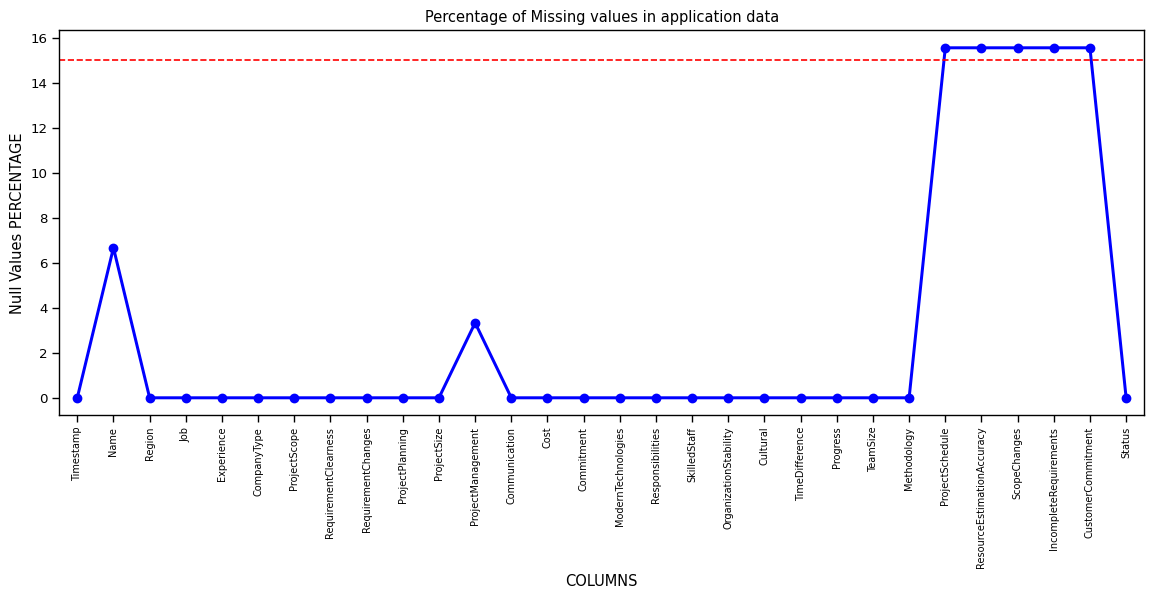

Total missing values After fillna :  9


In [207]:
####################################################
display_colored_message("FILL MISSING VALUES...")


null_applicationDF = pd.DataFrame((df.isnull().sum())*100/df.shape[0]).reset_index()
null_applicationDF.columns = ['Column Name', 'Null Values Percentage']
fig = plt.figure(figsize=(14,5))
ax = sns.pointplot(x="Column Name",y="Null Values Percentage",data=null_applicationDF,color='blue')
plt.xticks(rotation =90,fontsize =7)
ax.axhline(15, ls='--',color='red')
plt.title("Percentage of Missing values in application data")
plt.ylabel("Null Values PERCENTAGE")
plt.xlabel("COLUMNS")
plt.show()


def data_prep_fill_mising_values(data):
  #Missing Value
  # Status Column
  data['ProjectSchedule'] = data['ProjectSchedule'].fillna(data['ProjectSchedule'].mode()[0])
  data['ResourceEstimationAccuracy'] = data['ResourceEstimationAccuracy'].fillna(data['ResourceEstimationAccuracy'].mode()[0])
  data['ScopeChanges'] = data['ScopeChanges'].fillna(data['ScopeChanges'].mode()[0])
  data['IncompleteRequirements'] = data['IncompleteRequirements'].fillna(data['IncompleteRequirements'].mode()[0])
  data['CustomerCommitment'] = data['CustomerCommitment'].fillna(data['CustomerCommitment'].mode()[0])

data_prep_fill_mising_values(df)

print('Total missing values After fillna : ', df.isnull().sum().sum())

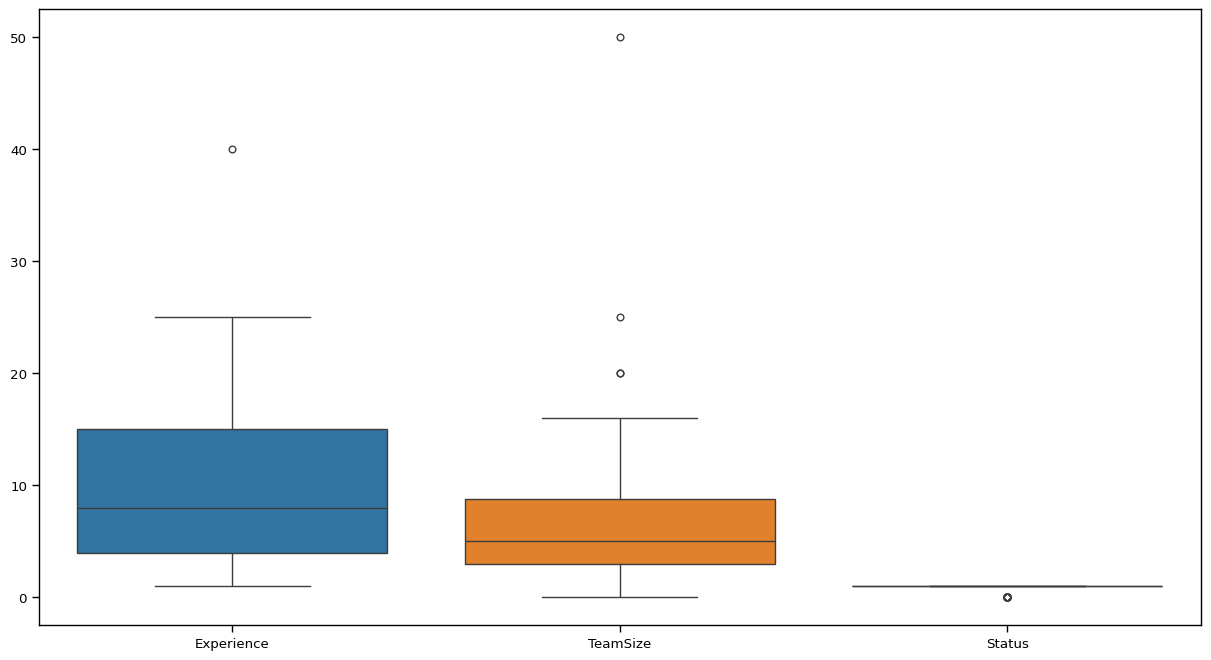

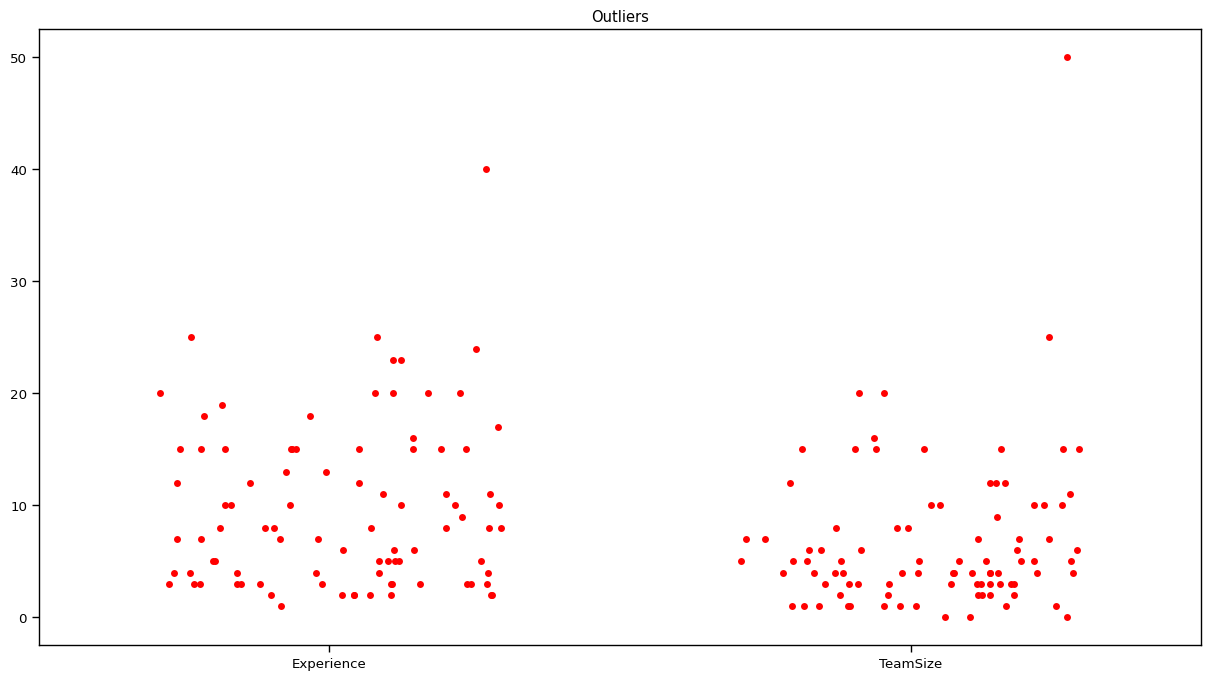

In [208]:
###################################################
display_colored_message("BOX PLOT DATASET...")
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.show()


display_colored_message("DISPLAY OUTLIERS...")
# Set the figure size
plt.figure(figsize=(15, 8))

# Only variables that have outliers
outliersColumns = df.get(["Experience", "TeamSize"])

# Add outliers to the plot
sns.stripplot(data=outliersColumns, color="red", jitter=0.3, size=5)

# Set the axis labels and title
plt.title("Outliers")

# Show the plot
plt.show()

Outliers lowerBound: 
 Experience   -12.500
TeamSize      -5.625
dtype: float64
Outliers upperBound: 
 Experience    31.500
TeamSize      17.375
dtype: float64


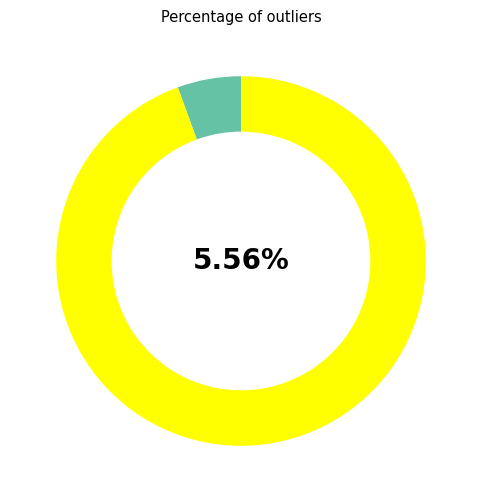

Outliers percentage too high > 5%


In [209]:
####################################################
display_colored_message("HANDLE OUTLIERS...")

def calculate_outliers(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    potential_outliers = df[columns][(df[columns] < lower_bound) | (df[columns] > upper_bound)]
    return lower_bound, upper_bound, potential_outliers

def plot_pie_chart(percent_outliers):
    fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(aspect="equal"))
    sizes = [percent_outliers * 100, 100 - (percent_outliers * 100)]
    colors = ['#66c2a5', 'Yellow']
    wedges, _ = ax.pie(sizes, colors=colors, startangle=90, wedgeprops=dict(width=0.3))
    plt.text(0, 0, f'{percent_outliers * 100:.2f}%', ha='center', va='center', fontsize=20, weight='bold')
    plt.title('Percentage of outliers')
    plt.show()

columns_to_check = ['Experience', 'TeamSize']
lower_bound, upper_bound, potential_outliers = calculate_outliers(df, columns_to_check)

print("Outliers lowerBound: \n", lower_bound)
print("Outliers upperBound: \n", upper_bound)

potential_outliers_row_count = potential_outliers.notnull().sum()
display_colored_message(f"\nSum of each outliers: {potential_outliers_row_count}", "blue")

unique_outlier_rows = potential_outliers.any(axis=1)
df_unique_outliers = df[unique_outlier_rows]
total_unique_outliers = df_unique_outliers.shape[0]
display_colored_message(f"\nTotal number of unique rows with outliers: {total_unique_outliers}", "blue")

percent_outliers = total_unique_outliers / df.shape[0]
display_colored_message(f"Percentage of outliers before treatment : {percent_outliers * 100:.2f}%", "blue")

plot_pie_chart(percent_outliers)

if 0 < percent_outliers < 0.05:
    display_colored_message("\nRemoving outliers", "blue")
else:
    print("Outliers percentage too high > 5%")


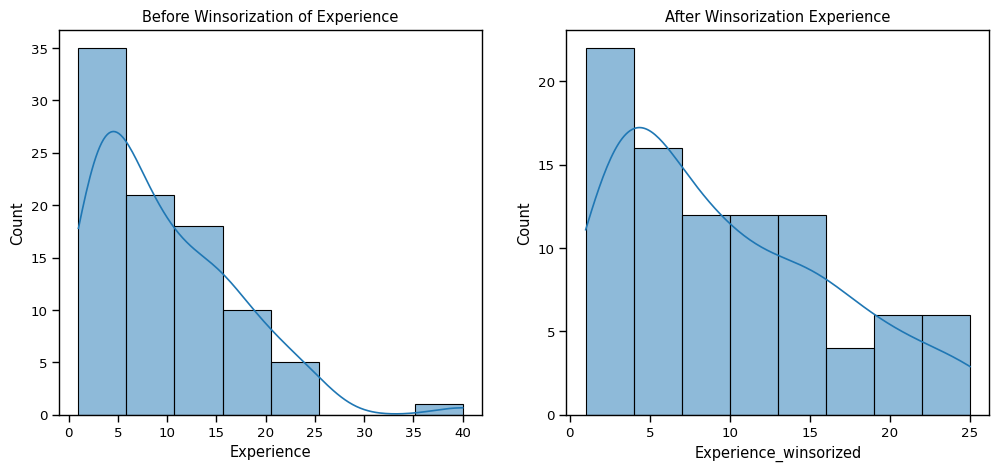

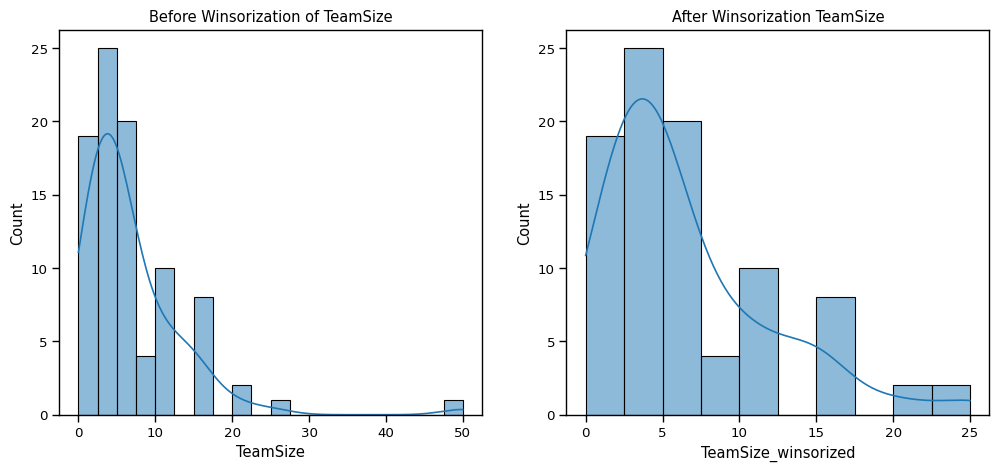

Outliers --lowerBound:
 Experience   -12.500
TeamSize      -5.625
dtype: float64
Outliers --upperBound:
 Experience    31.500
TeamSize      17.375
dtype: float64

Sum of each outliers:
 Experience    0
TeamSize      4
dtype: int64

Total number of unique rows with outliers:
 4
Percentage of outliers: 4.44%


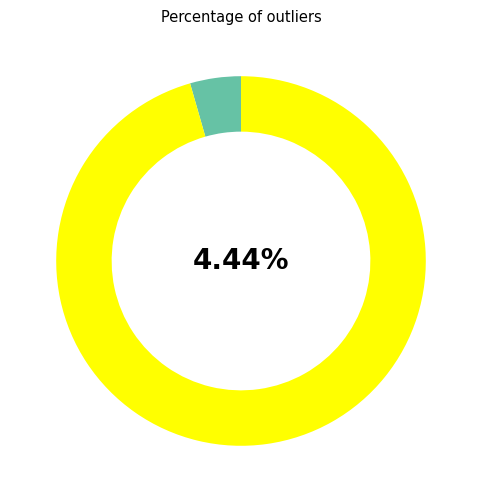

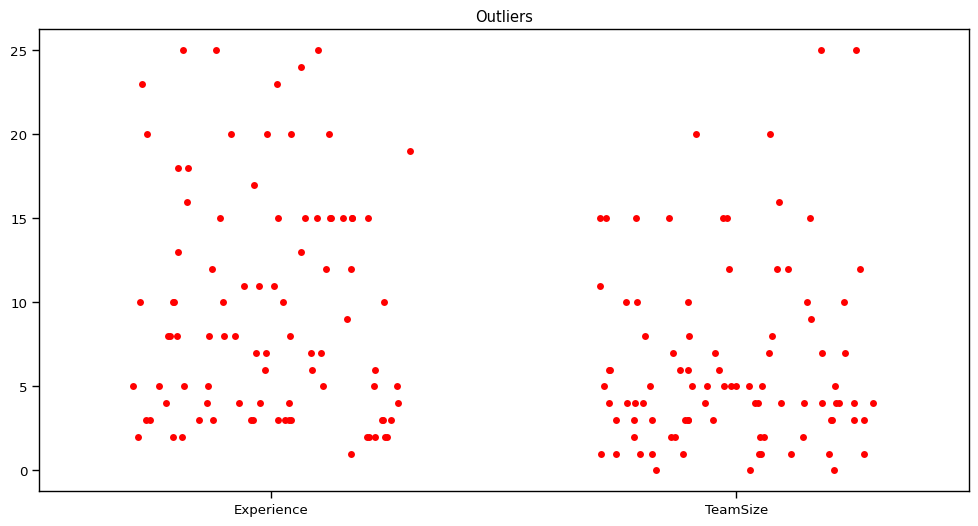

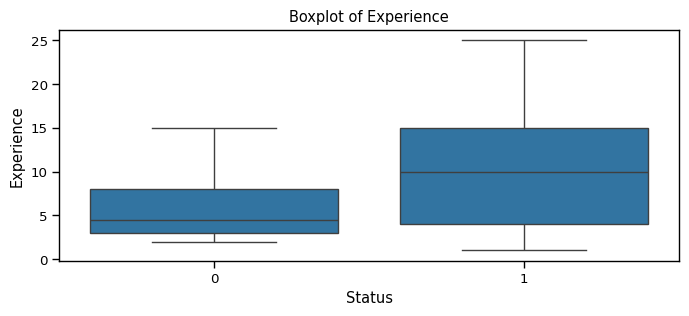

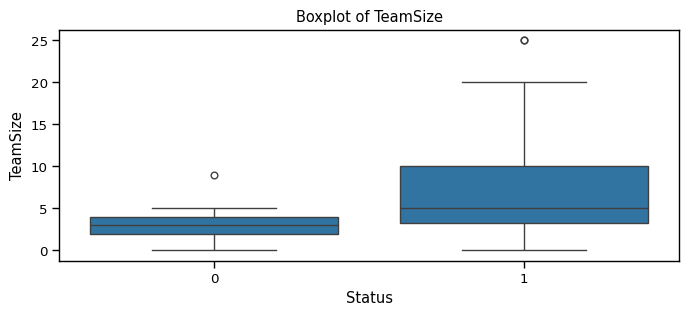

In [210]:
####################################################
display_colored_message("ADDRESS OUTLIERS...")

def winsorize_column(df, column, lower_limit, upper_limit, percentile):
    count = df[df[column] > upper_limit].shape[0]

    #percentile = (count / df.shape[0])
    display_colored_message(f'{column} [count < {upper_limit}] : {count}', "blue")
    display_colored_message(f'{column} [perc < {upper_limit}] : {percentile}', "blue")
    winsorized_column = f'{column}_winsorized'
    df[winsorized_column] = winsorize(df[column], limits=(0, percentile))
    plot_histograms(df, column, winsorized_column)
    df[column] = df[winsorized_column]

def plot_histograms(df, column, winsorized_column):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(df[column], kde=True)
    plt.title(f'Before Winsorization of {column}')
    plt.subplot(1, 2, 2)
    sns.histplot(df[winsorized_column], kde=True)
    plt.title(f'After Winsorization {column}')
    plt.show()

def plot_stripplot(df, columns):
    plt.figure(figsize=(12, 6))
    sns.stripplot(data=df[columns], color="red", jitter=0.3, size=5)
    plt.title("Outliers")
    plt.show()

def plot_boxplots(df, columns):
    for column in columns:
        plt.figure(figsize=(8, 3))
        sns.boxplot(x='Status', y=column, data=df)
        plt.title(f'Boxplot of {column}')
        plt.show()

df_winsorized = df.copy()

lower_bound, upper_bound, potential_outliers = calculate_outliers(df, columns_to_check)

# Winsorize the column 'ApplicantIncome', ApplicantIncome is the column with potential outliers,  ~ 0/50 = 0.001
winsorize_column(df_winsorized, 'Experience', lower_bound['Experience'], upper_bound['Experience'], 0.02)

# Winsorize the column 'CoapplicantIncome', CoapplicantIncome is the column with potential outliers ~ 1/50 = 0.02
winsorize_column(df_winsorized, 'TeamSize', lower_bound['TeamSize'], upper_bound['TeamSize'], 0.02)


df[columns_to_check] = df_winsorized[columns_to_check]

lower_bound, upper_bound, potential_outliers = calculate_outliers(df, columns_to_check)

print("Outliers --lowerBound:\n", lower_bound)
print("Outliers --upperBound:\n", upper_bound)
potential_outliers_row_count = potential_outliers.notnull().sum()
print("\nSum of each outliers:\n", potential_outliers_row_count)

unique_outlier_rows = potential_outliers.any(axis=1)
df_unique_outliers = df[unique_outlier_rows]
total_unique_outliers = df_unique_outliers.shape[0]
print("\nTotal number of unique rows with outliers:\n", total_unique_outliers)

percent_outliers = total_unique_outliers / df.shape[0]
print(f"Percentage of outliers: {percent_outliers * 100:.2f}%")
plot_pie_chart(percent_outliers)

plot_stripplot(df, columns_to_check)

plot_boxplots(df, columns_to_check)

In [211]:
##############################################
display_colored_message("\nchi2 CHECK...")

# Filter columns with 'object' dtype
categorical_columns = df.select_dtypes(include=['object']).columns
display_colored_sub_message("\nNull Hypothesis: there is no relation between categorical variables and Status")

chi2_check = []
for i in categorical_columns:
    if chi2_contingency(pd.crosstab(df['Status'], df[i]))[1] < 0.05:
        chi2_check.append('Reject Null Hypothesis')
    else:
        chi2_check.append('Fail to Reject Null Hypothesis')


res = pd.DataFrame({'Column': categorical_columns, 'Hypothesis': chi2_check})

# Define a function to color the cells
def color_hypothesis(val):
    color = 'green' if val == 'Reject Null Hypothesis' else 'red'
    return f'color: {color}'

# Apply the coloring function to the Hypothesis column
styled_res = res.style.applymap(color_hypothesis, subset=['Hypothesis'])

# Display the styled DataFrame
styled_res


Null Hypothesis: there is no relation between categorical variables and Status


,Column,Hypothesis
0,Timestamp,Fail to Reject Null Hypothesis
1,Name,Fail to Reject Null Hypothesis
2,Region,Fail to Reject Null Hypothesis
3,Job,Fail to Reject Null Hypothesis
4,CompanyType,Fail to Reject Null Hypothesis
5,ProjectScope,Reject Null Hypothesis
6,RequirementClearness,Reject Null Hypothesis
7,RequirementChanges,Reject Null Hypothesis
8,ProjectPlanning,Reject Null Hypothesis
9,ProjectSize,Reject Null Hypothesis


In [212]:
####################################################
display_colored_message("CROSSTAB SkilledStaff vs status...")
pivot = pd.crosstab(df.Status, df.SkilledStaff, margins=True)

pivot_percentage = pd.crosstab(df.Status, df.SkilledStaff, normalize='index', margins=True) * 100
pivot_percentage = pivot_percentage.round(2).astype(str) + '%'

print('Numbers:')
print(pivot.to_string())

print('\nPercentage:')
print(pivot_percentage.to_string())

Numbers:
SkilledStaff  Agree  Disagree  Moderate  All
Status                                      
0                 0         9         7   16
1                42         5        27   74
All              42        14        34   90

Percentage:
SkilledStaff   Agree Disagree Moderate
Status                                
0               0.0%   56.25%   43.75%
1             56.76%    6.76%   36.49%
All           46.67%   15.56%   37.78%


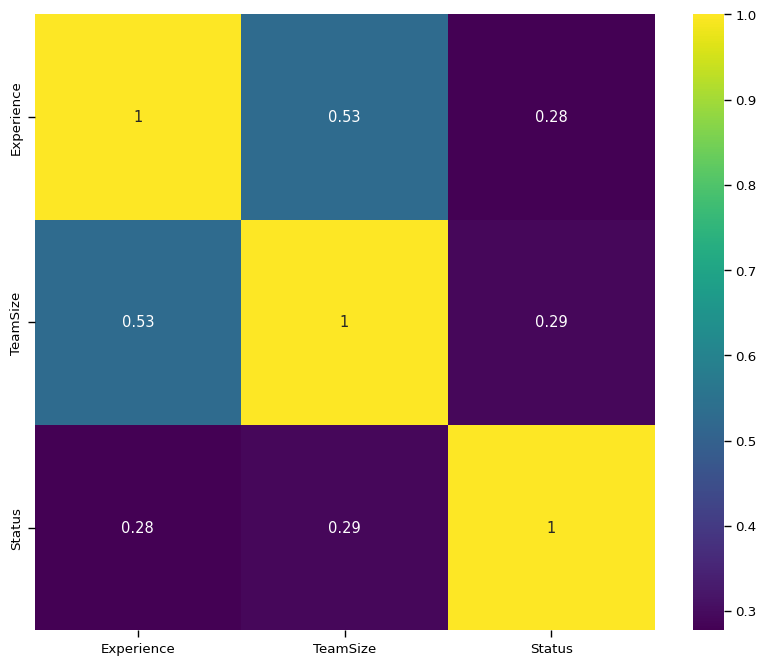

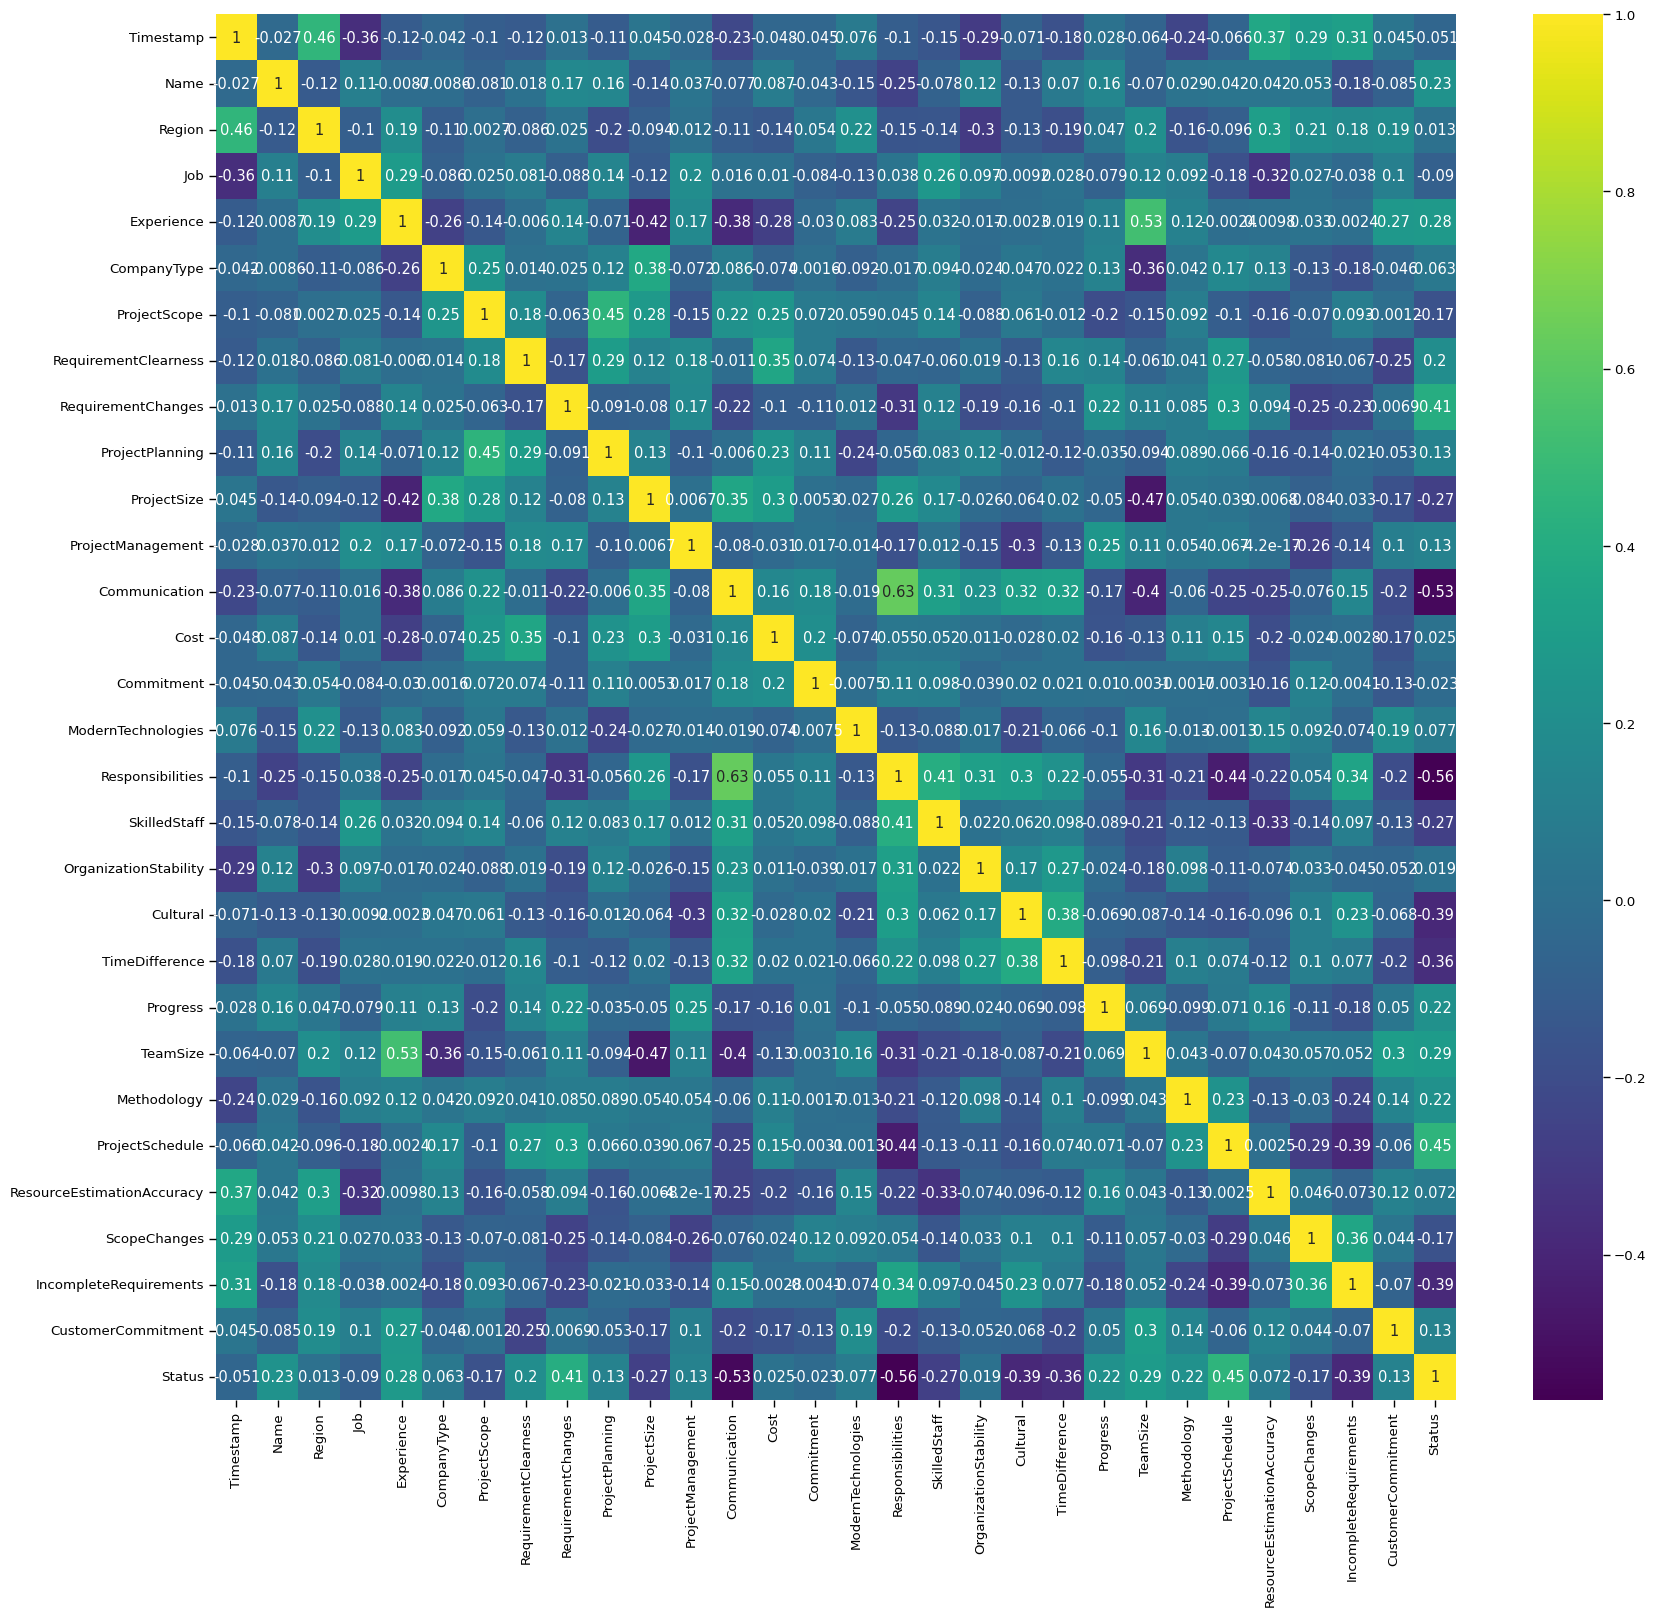

In [213]:
####################################################
display_colored_message("DISPLAY CORRELATION...")
dfCopy = df.copy()
# Filter columns with 'object' dtype
object_columns = dfCopy.select_dtypes(include=['object']).columns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="viridis")
plt.show()

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to 'object' columns
for col in object_columns:
    dfCopy[col] = le.fit_transform(dfCopy[col])

plt.figure(figsize=(20,18))
sns.heatmap(dfCopy.corr(),annot=True,cmap="viridis")
plt.show()

In [214]:
####################################################
display_colored_message("DROP COLUMNS...")
# Drop columns
columns_to_drop = ['Timestamp', 'Name']
df.drop(columns_to_drop, axis=1, inplace=True)


#TO BE USED FOR REMOVE ALL DROPPED COLUMNS IN TESTING
ALL_DROPPED_COLUMNS = columns_to_drop;

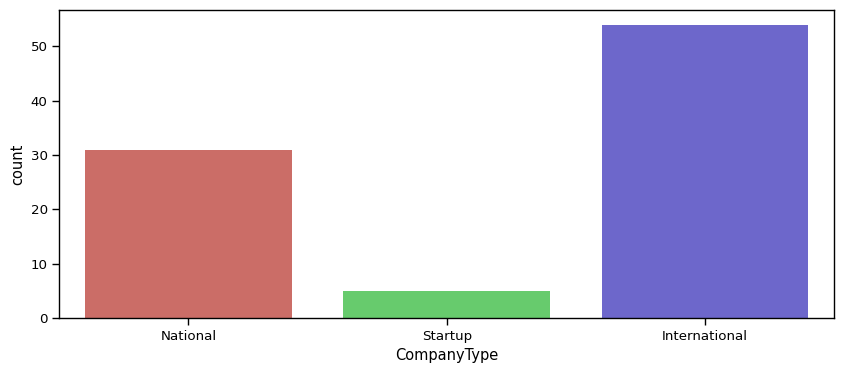

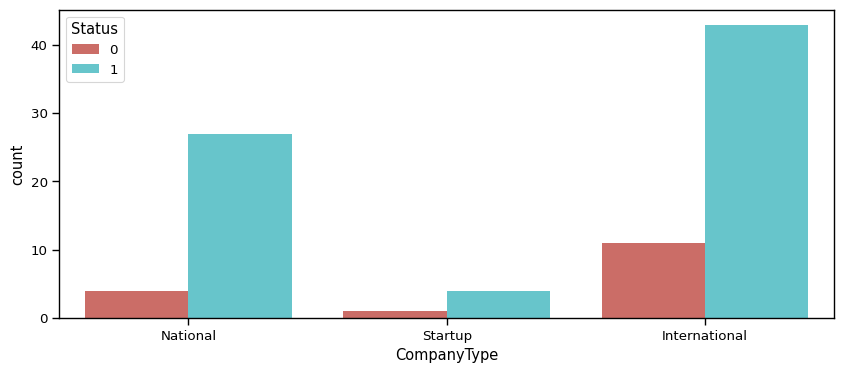

<Figure size 1800x600 with 0 Axes>

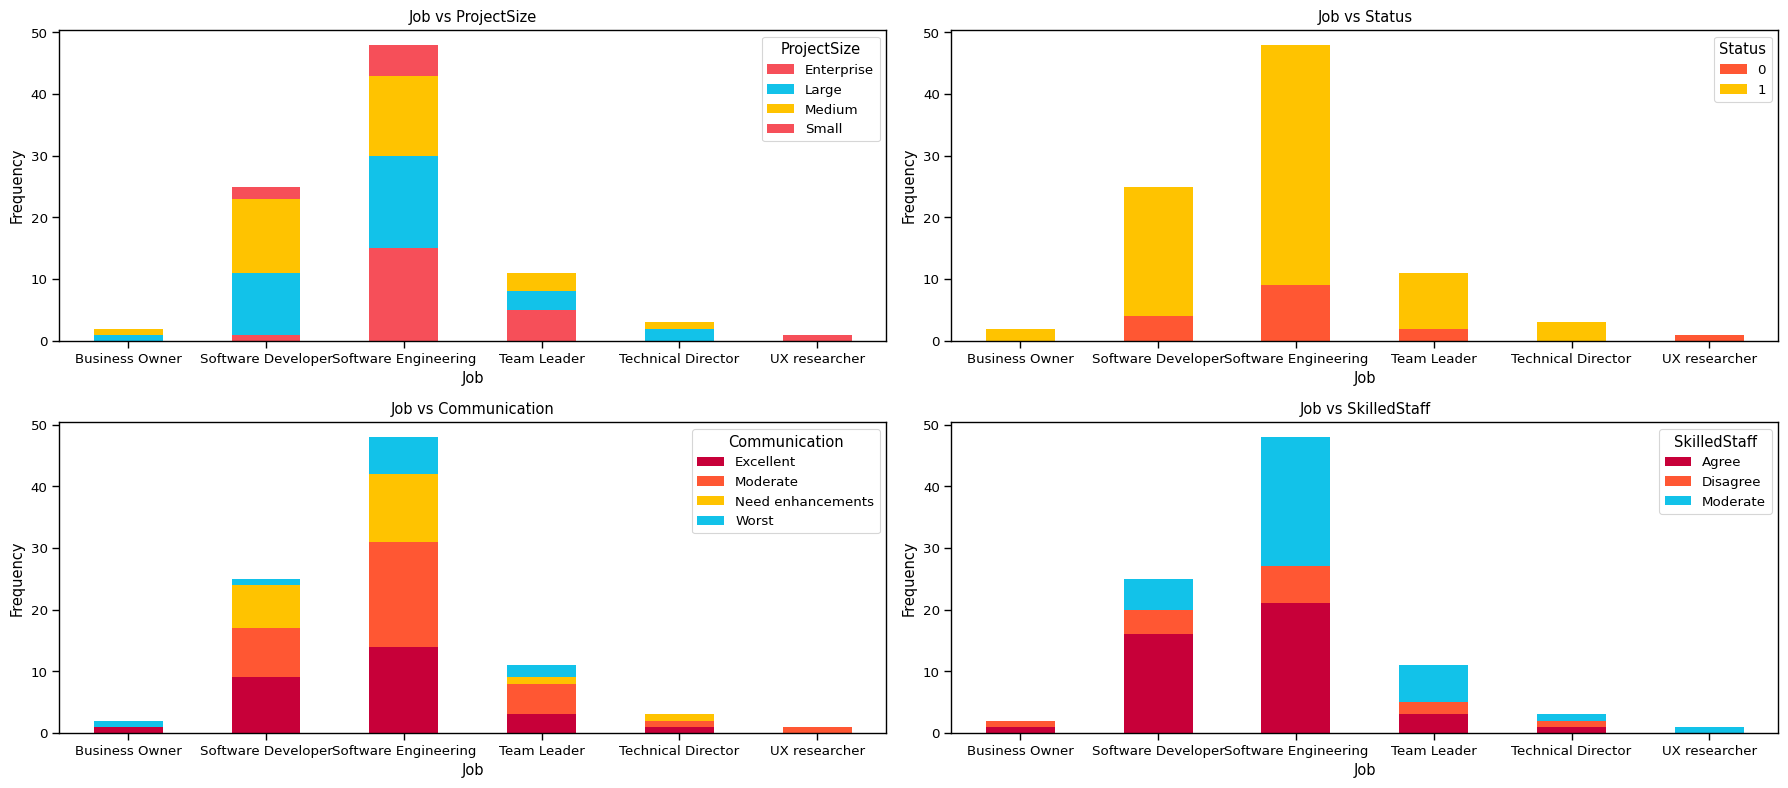

In [215]:
####################################################
display_colored_message("DATA VISULIZATION...")

# Counting the accurance of each value in CompanyType column
df['CompanyType'].value_counts()

plt.figure(figsize=(10, 4))
sns.countplot(x='CompanyType', data=df, palette='hls')
plt.show()

# comparing project status with CompanyType column
plt.figure(figsize=(10,4))
sns.countplot(x = 'CompanyType',hue ='Status', data=df , palette='hls')
plt.show()

#Married people collect more project than unmarried
#Counting the occurence of each value with Experience column
df['Experience'].value_counts()
plt.figure(figsize=(18,6))
#sns.countplot('Experience', data = df, palette='hls')
#plt.xticks(rotation = 90)
#plt.show()

# Creating cross-tabulations
crosstab1 = pd.crosstab(df.Job, df.ProjectSize)
crosstab2 = pd.crosstab(df.Job, df.Status)
crosstab3 = pd.crosstab(df.Job, df.Communication)
crosstab4 = pd.crosstab(df.Job, df.SkilledStaff)

# Plotting the cross-tabulations in subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 8))

# Job vs ProjectSize
crosstab1.plot(kind="bar", stacked=True, ax=axes[0,0], color=['#f64f59', '#12c2e9', '#FFC300'])
axes[0,0].set_title('Job vs ProjectSize')
axes[0,0].set_xlabel('Job')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_xticklabels(axes[0,0].get_xticklabels(), rotation=0)

# Job vs Status
crosstab2.plot(kind="bar", stacked=True, ax=axes[0,1], color=['#FF5733', '#FFC300'])
axes[0,1].set_title('Job vs Status')
axes[0,1].set_xlabel('Job')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=0)

# Job vs Communication
# For Communication, we will use a different kind of plot since it's continuous data.
crosstab3.plot(kind="bar", stacked=True, ax=axes[1,0], color=['#C70039', '#FF5733', '#FFC300', '#12c2e9'])
axes[1,0].set_title('Job vs Communication')
axes[1,0].set_xlabel('Job')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)

# Job vs SkilledStaff
# For SkilledStaff, we will use a different kind of plot since it's continuous data.
crosstab4.plot(kind="bar", stacked=True, ax=axes[1,1], color=['#C70039', '#FF5733', '#12c2e9'])
axes[1,1].set_title('Job vs SkilledStaff')
axes[1,1].set_xlabel('Job')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_xticklabels(axes[1,1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

In [216]:
####################################################
display_colored_message("\n3D SCATTER PLOT OF RiSk (TeamSize, Experience) BY STATUS AND Region...")

plt.figure(figsize=(15, 10))
fig = px.scatter_3d(df,
                    x='TeamSize',
                    y='Experience',
                    z='SkilledStaff',
                    color='Status',
                    size='Experience',
                    size_max=18,
                    symbol='Region',
                    opacity=0.7,
                    title='3D Scatter Plot of Risk Data',
                    labels={
                        'TeamSize': 'TeamSize',
                        'Experience': 'Experience',
                        'SkilledStaff': 'Skilled Staff',
                        'Status': 'Status',

                        'Region': 'Region'
                    })

fig.update_layout(margin=dict(l=0, r=0, b=0, t=0),
                  scene=dict(
                      xaxis_title='Team Size',
                      yaxis_title='Experience',
                      zaxis_title='Skilled Staff',
                  ))

fig.show()

<Figure size 1500x1000 with 0 Axes>

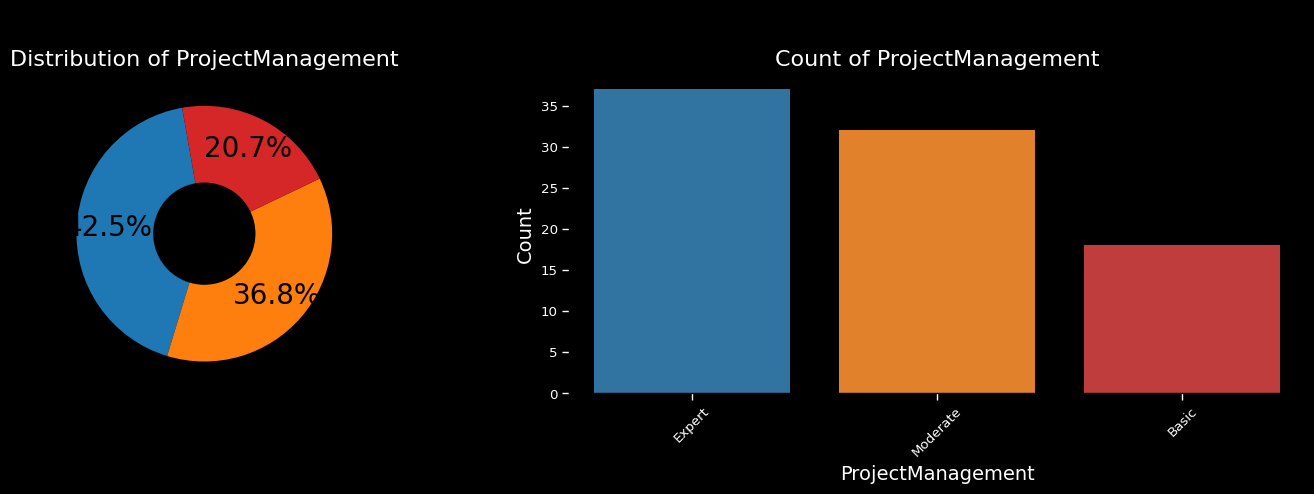

In [217]:
####################################################
display_colored_message("PLOT DISTRIBUTION OF PROJECTMANAGEMENT...")
def single_plot_distribution(column_name, dataframe, title):

    # Get the value counts of the specified column
    value_counts = dataframe[column_name].value_counts()

    # Set up the figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), facecolor='black')

    # Set main title for the figure
    fig.suptitle(title)

    # Pie chart
    pie_colors = ['#1f77b4', '#ff7f0e', '#d62728']
    ax1.pie(value_counts, autopct='%0.001f%%', startangle=100, textprops={'fontsize': 20}, pctdistance=0.75, colors=pie_colors, labels=None)
    centre_circle = plt.Circle((0,0),0.40,fc='black')
    ax1.add_artist(centre_circle)
    ax1.set_title(f'Distribution of {column_name}', fontsize=16, color='white')

    # Bar chart
    sns.barplot(x=value_counts.index, y=value_counts.values, ax=ax2, palette=pie_colors)
    ax2.set_title(f'Count of {column_name}', fontsize=16, color='white')
    ax2.set_xlabel(column_name, fontsize=14, color='white')
    ax2.set_ylabel('Count', fontsize=14, color='white')

    # Rotate x-axis labels for better readability
    ax2.tick_params(axis='x', rotation=45, colors='white')
    ax2.tick_params(axis='y', colors='white')

    # Set background color for the subplots
    ax1.set_facecolor('black')
    ax2.set_facecolor('black')

    # Show the plots
    plt.tight_layout()
    plt.show()

# Plot the distribution of ProjectManagement in the dataset
single_plot_distribution('ProjectManagement', df, 'Project Management Distribution')

In [218]:

####################################################
display_colored_message("\nGROUP BY JOB AND CALCULATE MEAN EXPERIENCE...")
print("\n")
# Group the DataFrame by 'Job' and calculate the mean of 'EXPERIENCE'
np = round(df.groupby('Job')['Experience'].mean().round(1))

def bar_charts(x, y, title):
    # Create a bar chart using Plotly Express
    fig = px.bar(
        x=x,  # Data for the x-axis
        y=y,  # Data for the y-axis
        title=title,  # Title of the chart
        color=y,  # Color the bars based on y-values
        labels={'x': 'Job', 'y': 'Average Experience'},  # Custom axis labels
        text=y  # Add text labels to the bars
        ,width=900, height=500
    )

    # Use a dark template
    fig.update_layout(template='plotly_dark')

    fig.show()

# Call the bar_charts function to generate a bar chart
bar_charts(
    np.index,           # Data for the x-axis (gender)
    np.values,          # Data for the y-axis (average Experience)
    'Average Job by EXPERIENCE'  # Title of the chart
)

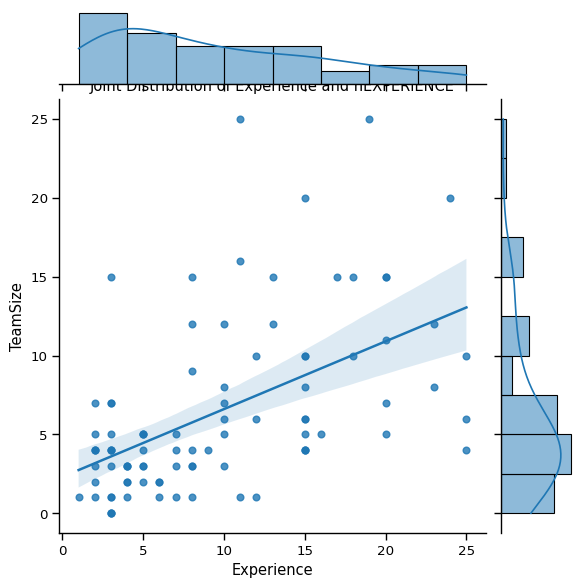

In [219]:
####################################################
display_colored_message("\nEXPERIENCE JOIN PLOT TEAMSIZE")
sns.jointplot(x='Experience', y='TeamSize', data=df, kind='reg')
plt.title('Joint Distribution of Experience and nEXPERIENCE')
plt.show()


df_counts = df['Progress'].value_counts().reset_index()
df_counts.columns = ['Progress', 'Count']
df_counts['Percentage'] = (df_counts['Count'] / df_counts['Count'].sum()) * 100

# Create a donut chart
fig = px.pie(df_counts, names='Progress', values='Percentage',
             title="Percentage Distribution of Progress Level ",
             hole=0.5,  # Size of the hole
             color='Progress')

# Update layout
fig.update_layout(
    title="Percentage Distribution of Progress Level",
    title_x=0.3,
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Show the plot
fig.show()




In [220]:
####################################################
display_colored_message("\nMEAN TEAM SIZE BY PROJECT STATUS...")

# Group by 'Status' and calculate mean 'ApplicantIncome'
income_mean = df.groupby('Status')['TeamSize'].mean().reset_index()

# Create advanced bar chart using Plotly Express
fig = px.bar(income_mean, x='Status', y='TeamSize',
             color='Status',
             labels={'TeamSize': 'Mean Team Size'},
             title='Mean TeamS ize by Project Status',
             text='TeamSize',
             width=900, height=500)

# Update layout
fig.update_layout(xaxis_title='Project Status', yaxis_title='Mean Team Size',
                  showlegend=False, barmode='group')

# Show the plot
fig.show()

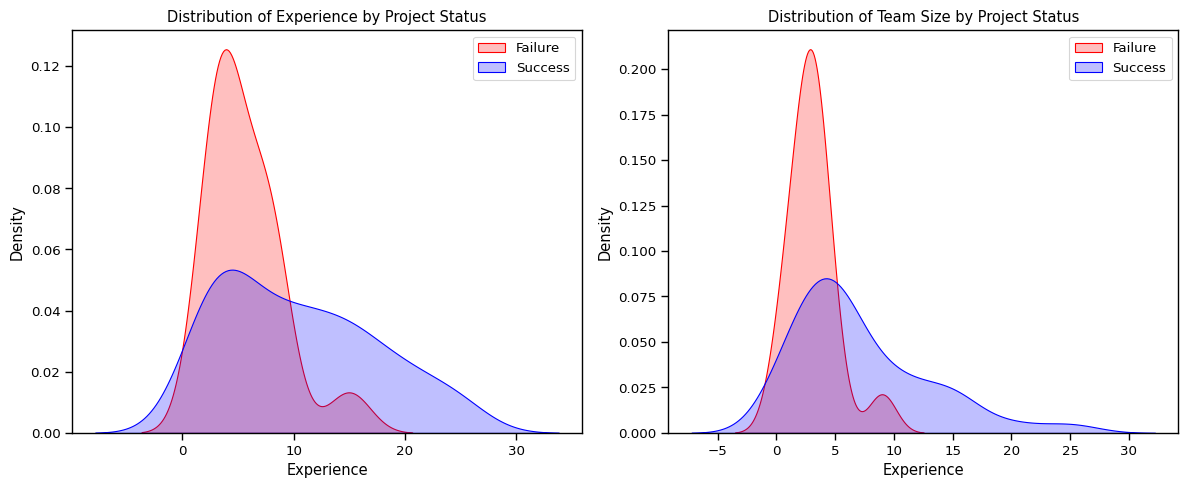

In [221]:
####################################################
display_colored_message("\nPROJECT PROJECT STATUS DISTRIBUTION - Experience...")

# Set the style and context for seaborn
sns.set_context("paper", font_scale=1.1)

# Create two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Distribution of Experience Term by Project status
sns.kdeplot(df.Experience[df["Status"] == 0], color="Red", shade=True, ax=axes[0])
sns.kdeplot(df.Experience[df["Status"] == 1], color="Blue", shade=True, ax=axes[0])
axes[0].legend(["Failure", "Success"], loc='upper right')
axes[0].set_ylabel('Density')
axes[0].set_xlabel('Experience')
axes[0].set_title('Distribution of Experience by Project Status')

# Plot 2: Distribution of Experience by Project status
sns.kdeplot(df.TeamSize[df["Status"] == 0], color="Red", shade=True, ax=axes[1])
sns.kdeplot(df.TeamSize[df["Status"] == 1], color="Blue", shade=True, ax=axes[1])
axes[1].legend(["Failure", "Success"], loc='upper right')
axes[1].set_ylabel('Density')
axes[1].set_xlabel('Experience')
axes[1].set_title('Distribution of Team Size by Project Status')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

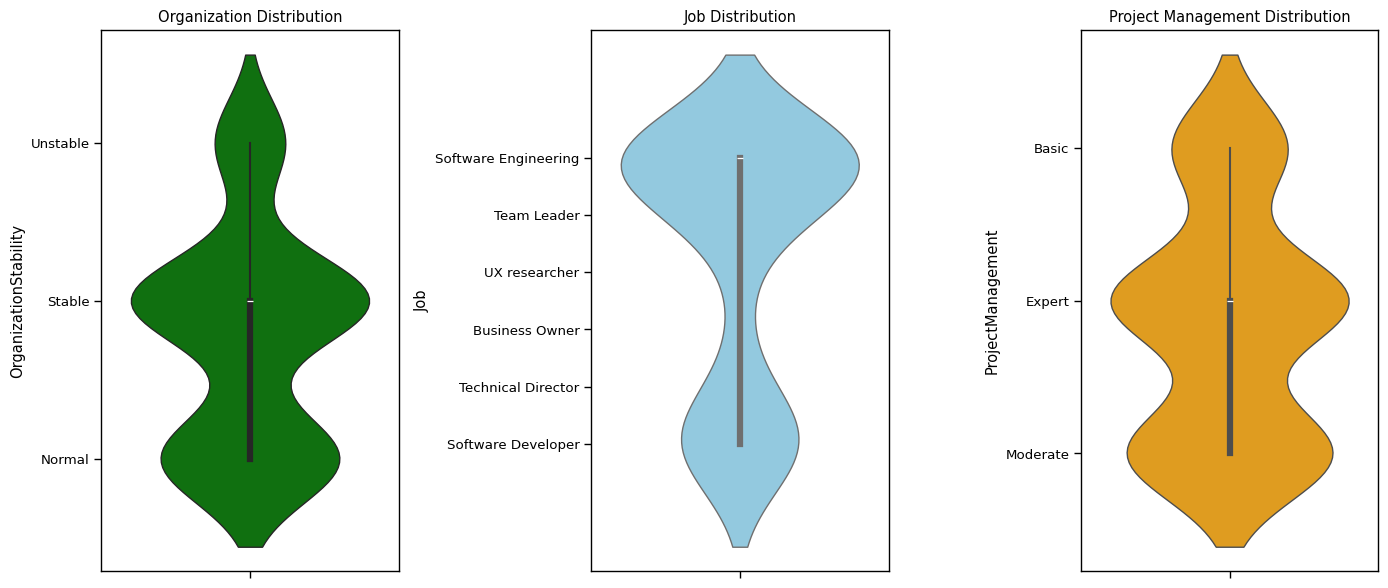

In [222]:
####################################################
display_colored_message("\nPROJECT DISTRIBUTION...")
fig, axs1 = plt.subplots(1, 3, figsize=(14, 6))

# Create violin plots for OrganizationStability, Job, and ProjectManagement
sns.violinplot(data=df, y="OrganizationStability", ax=axs1[0], color='green')
axs1[0].set_title('Organization Distribution')

sns.violinplot(data=df, y="Job", ax=axs1[1], color='skyblue')
axs1[1].set_title('Job Distribution')

sns.violinplot(data=df, y="ProjectManagement", ax=axs1[2], color='orange')
axs1[2].set_title('Project Management Distribution')

# Adjust layout
plt.tight_layout()
plt.show()

In [223]:
####################################################
display_colored_message("\nPIE VISULIZATION...")

#DATA visulazation
d_labels = ['Enterprise', 'Larhge', 'Medium', 'Small']
g_labels = ['Many', 'Normal', 'Few']
p_labels = ['Agree', 'Moderate', 'Disagree']
l_labels = ['Success', 'Failure']

# Create subplots: use 'domain' type for Pie subplot
fig = make_subplots(rows=1, cols=4, specs=[[{'type':'domain'}, {'type':'domain'}, {'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=d_labels, values=df['ProjectSize'].value_counts(), name="ProjectSize"),
              1, 1)
fig.add_trace(go.Pie(labels=g_labels, values=df['ModernTechnologies'].value_counts(), name="ModernTechnologies"),
              1, 2)
fig.add_trace(go.Pie(labels=p_labels, values=df['SkilledStaff'].value_counts(), name="SkilledStaff"),
              1, 3)
fig.add_trace(go.Pie(labels=l_labels, values=df['Status'].value_counts(), name="Status"),
              1, 4)


# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.4, hoverinfo="label+percent+name", textfont_size=16)

fig.update_layout(
    title_text="Project Size, modern Technologies, Skilled Staff and Project Status Distributions",
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Project Size', x=0.1, y=0.3, font_size=20, showarrow=False),
                 dict(text='Modern Technologies', x=0.3, y=0.6, font_size=20, showarrow=False),
                 dict(text='Skilled Staff', x=0.6, y=0.9, font_size=20, showarrow=False),
                 dict(text='Project Status', x=0.9, y=0.5, font_size=20, showarrow=False)])
fig.show()

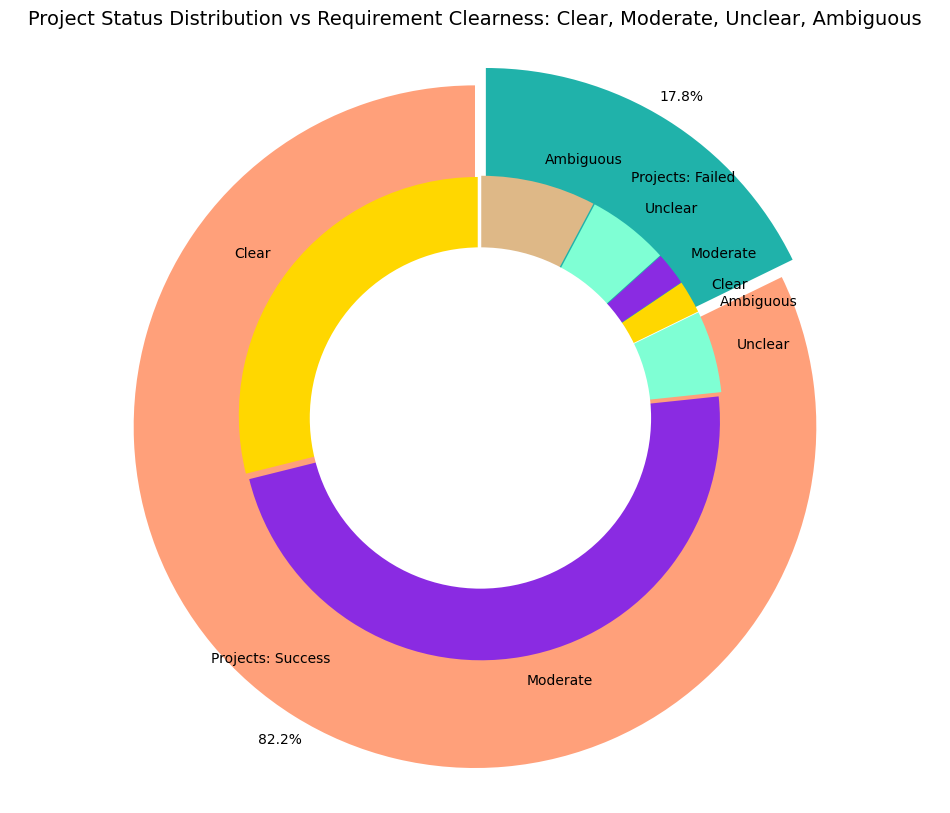

In [224]:
####################################################
display_colored_message("\nPIE PROJECT STATUS DISTRIBUTION VS REQUIREMENT CLEARNESS...")

# Find the most repeated RequirementClearness value for each Status
mode = df.groupby('Status')['RequirementClearness'].apply(lambda x: x.mode().iloc[0]).to_dict()

# Replace None values in RequirementClearness column based on Status
for index, row in df.iterrows():
    if pd.isnull(row['RequirementClearness']):
        df.at[index, 'RequirementClearness'] = mode[row['Status']]



# Group by RequirementClearness the the succeded projects
project_success_counts = df[df["Status"] == 1].groupby("RequirementClearness").size()

# Group by RequirementClearness the failed projects
project_failed_counts = df[df["Status"] == 0].groupby("RequirementClearness").size()

# Data for the outer pie chart (distribution of project status by RequirementClearness)
labels = ["Clear", "Moderate", "Unclear", "Ambiguous", "Clear", "Moderate", "Unclear", "Ambiguous"]
sizes = [
    project_success_counts.get('Clear', 0), project_success_counts.get('Moderate', 0), project_success_counts.get('Unclear', 0), project_success_counts.get('Ambiguous', 0),
    project_failed_counts.get('Clear', 0), project_failed_counts.get('Moderate', 0), project_failed_counts.get('Unclear', 0), project_failed_counts.get('Ambiguous', 0)
]

labels_risk =["Projects: Success", "Projects: Failed"]
values_risk = [sum(project_success_counts), sum(project_failed_counts)]

# Colors
colors_status = ['#ffa07a', '#20b2aa']  # Coral and light sea green for inner pie chart
colors = ['#ffd700', '#8a2be2', '#7fffd4', '#deb887', '#ffd700', '#8a2be2', '#7fffd4', '#deb887']  # Gold, blue violet, aquamarine, and burlywood for outer pie chart


# Explode
explode_status = (0.3,0.3)
explode = (0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1)

# Plot
plt.figure(figsize=(12, 10))
textprops = {"fontsize":10}

#Plot
plt.pie(values_risk, labels=labels_risk,autopct='%1.1f%%',pctdistance=1.08, labeldistance=0.8,colors=colors_status, startangle=90,frame=True, explode=explode_status,radius=10, textprops =textprops, counterclock = True, )
plt.pie(sizes,labels=labels,colors=colors,startangle=90, explode=explode,radius=7, textprops =textprops, counterclock = True, )
#Draw circle
centre_circle = plt.Circle((0,0),5,color='black', fc='white',linewidth=0)
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Set equal aspect ratio
plt.axis('equal')

plt.title('Project Status Distribution vs Requirement Clearness: Clear, Moderate, Unclear, Ambiguous', fontsize=14, y=1)
plt.show()


# Aggregate data
df_agg = df.groupby(['CompanyType', 'Region', 'Status']).size().reset_index(name='Count')

# Create a sunburst plot
fig = px.sunburst(df_agg, path=['CompanyType', 'Region'], values='Count')

# Update layout with title, title position, and figure size
fig.update_layout(
    title="Placement % of Company Type by Region",
    title_x=0.5,
    width=800,  # Width of the plot in pixels
    height=600  # Height of the plot in pixels
)

# Show the plot
fig.show()

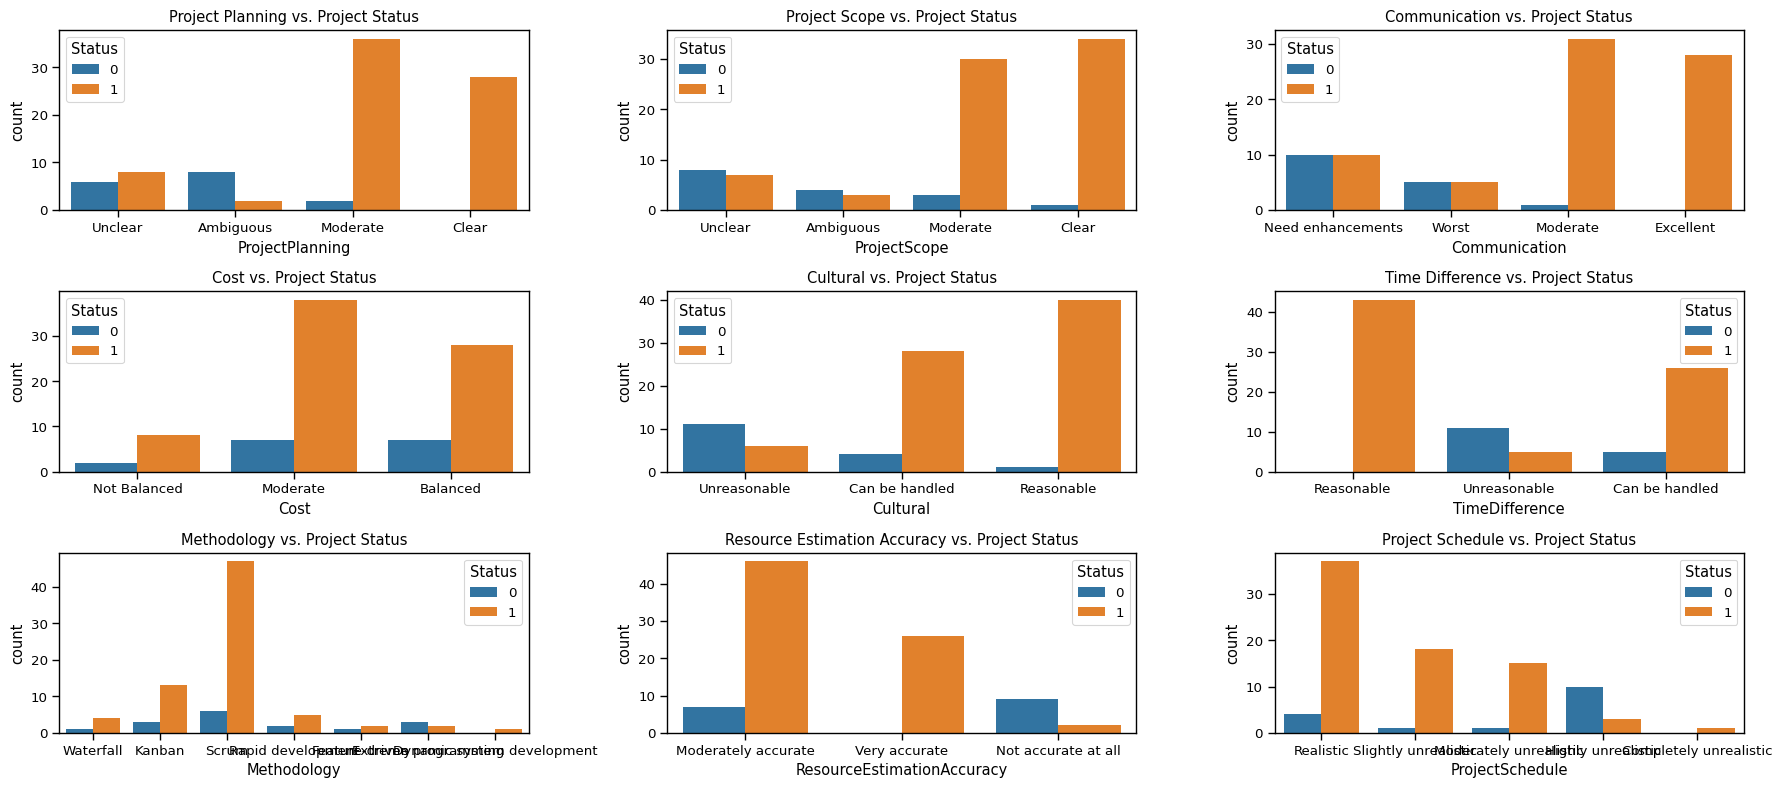

In [225]:
####################################################
display_colored_message("\n PROJECT STATUS DISTRIBUTION...")

# Create a figure with multiple subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 8))

# Plot 1: Project Planning vs. Project Status
sns.countplot(x='ProjectPlanning', hue='Status', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Project Planning vs. Project Status')

# Plot 2: Project Scope vs. Project Status
sns.countplot(x='ProjectScope', hue='Status', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Project Scope vs. Project Status')

# Plot 3: Communication vs. Project Status
sns.countplot(x='Communication', hue='Status', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Communication vs. Project Status')

# Plot 4: Cost vs. Project Status
sns.countplot(x='Cost', hue='Status', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Cost vs. Project Status')

# Plot 5: Cultural vs. Project Status
sns.countplot(x='Cultural', hue='Status', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Cultural vs. Project Status')

# Plot 6: Time Difference vs. Project Status
sns.countplot(x='TimeDifference', hue='Status', data=df, ax=axes[1, 2])
axes[1, 2].set_title('Time Difference vs. Project Status')

# Plot 7: Methodology vs. Project Status
sns.countplot(x='Methodology', hue='Status', data=df, ax=axes[2, 0])
axes[2, 0].set_title('Methodology vs. Project Status')

# Plot 8: Resource Estimation Accuracy vs. Project Status
sns.countplot(x='ResourceEstimationAccuracy', hue='Status', data=df, ax=axes[2, 1])
axes[2, 1].set_title('Resource Estimation Accuracy vs. Project Status')

# Plot 9: Project Schedule vs. Project Status
sns.countplot(x='ProjectSchedule', hue='Status', data=df, ax=axes[2, 2])
axes[2, 2].set_title('Project Schedule vs. Project Status')


# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

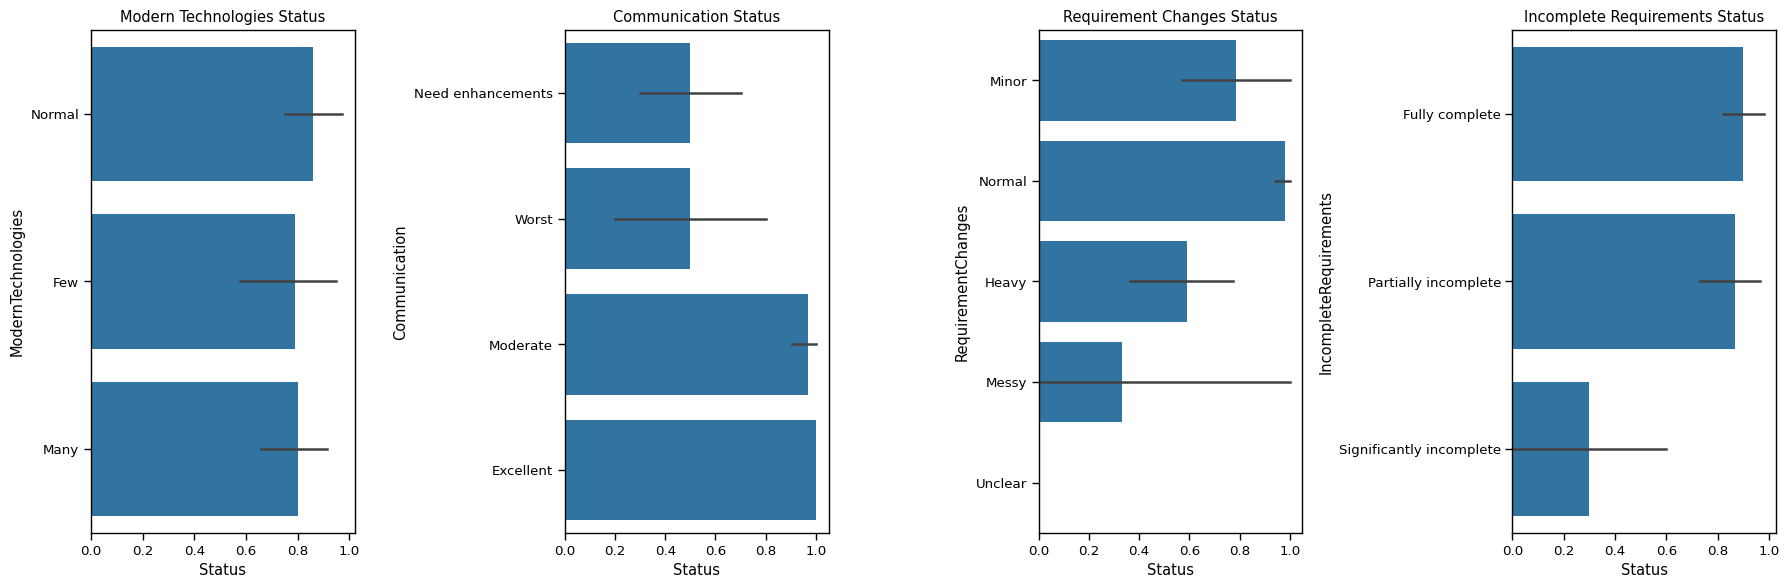

In [226]:

####################################################
display_colored_message("\n PROJECT STATUS DISTRIBUTION...")

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

# First plot: Modern Technologiess Status Plot
sns.barplot(y='ModernTechnologies', x='Status', data=df, ax=axes[0])
axes[0].set_title('Modern Technologies Status')

# Second plot: Communication Status Plot
sns.barplot(y='Communication', x='Status', data=df, ax=axes[1])
axes[1].set_title('Communication Status')

# Third plot: Requirement Changes Status Plot
sns.barplot(y='RequirementChanges', x='Status', data=df, ax=axes[2])
axes[2].set_title('Requirement Changes Status')


# Third plot: Incomplete Requirements Status Plot
sns.barplot(y='IncompleteRequirements', x='Status', data=df, ax=axes[3])
axes[3].set_title('Incomplete Requirements Status')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()


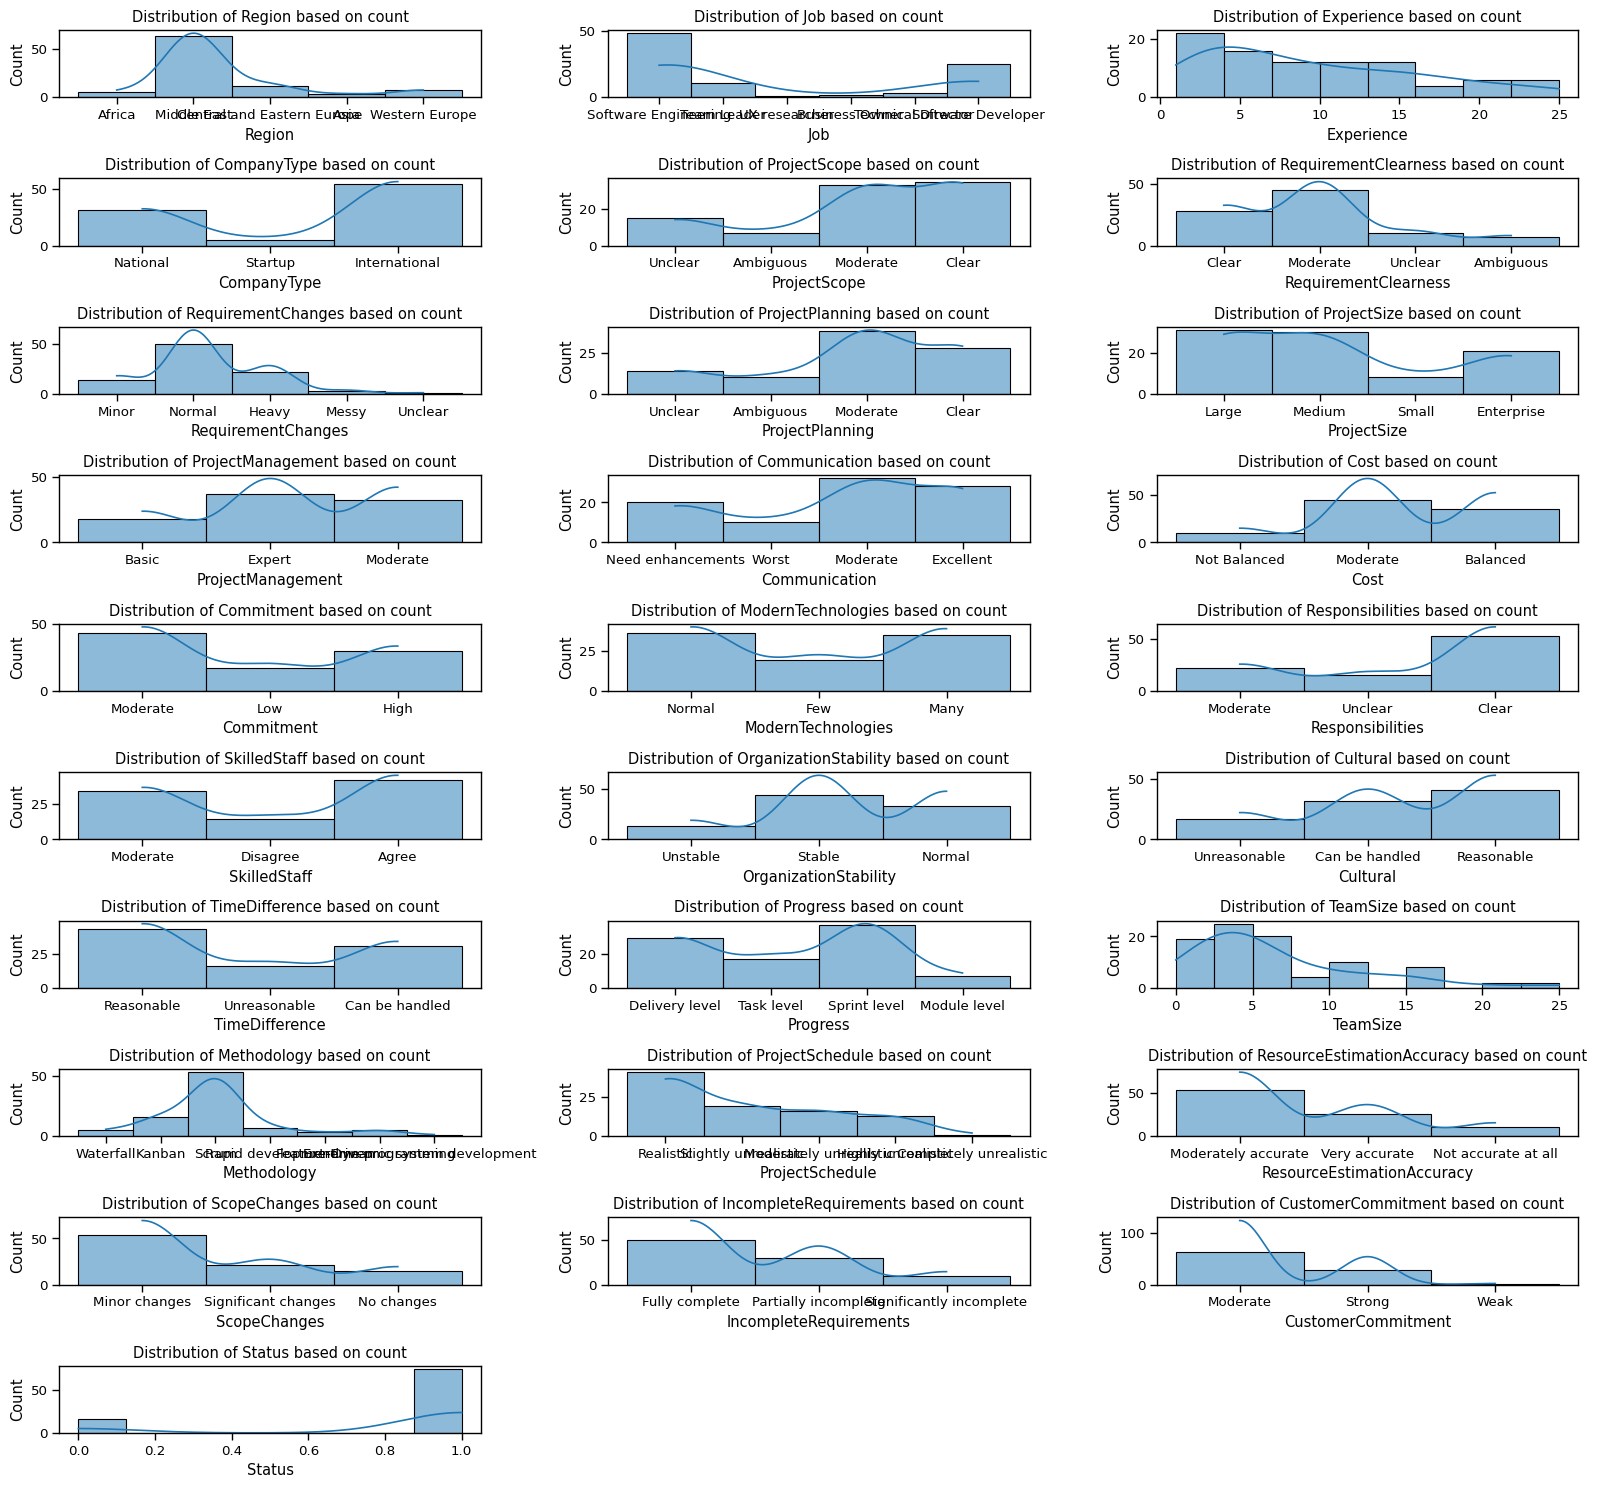

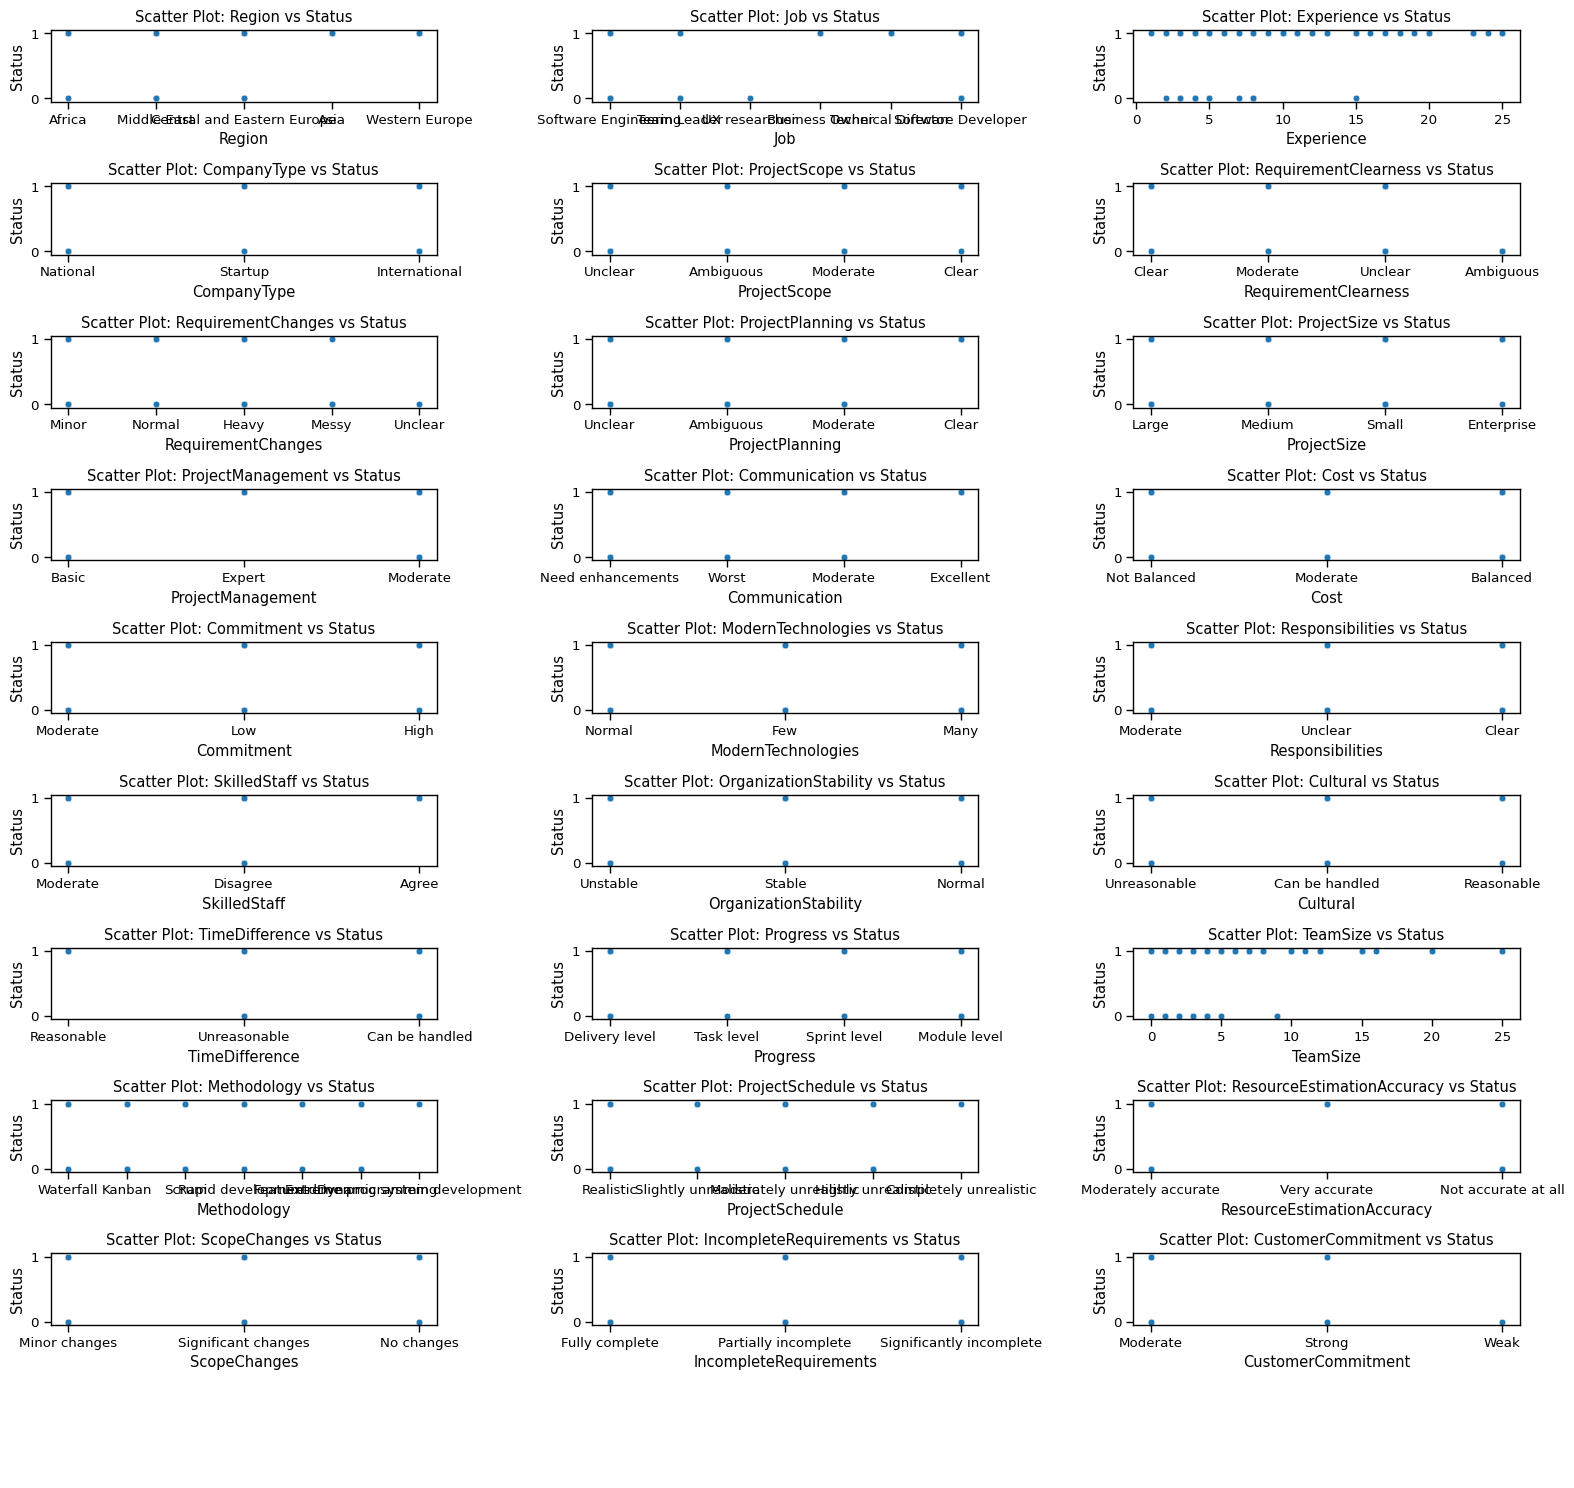

In [227]:
####################################################
display_colored_message("\n DISTRIBUTION BASED ON COUNT...")

num_cols = 3
num_rows = (len(df.columns) + num_cols - 1) // num_cols

# Create a figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 15))

# Flatten the axes if needed
axes = axes.flatten()

# Loop through each column and plot the distribution
for i, column in enumerate(df.columns):
    sns.histplot(df[column], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {column} based on count')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

# Create subplots
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 15))

# Flatten the axes if needed
axes = axes.flatten()

# Iterate through each feature column (excluding the target variable)
for i, column in enumerate(df.columns[:-1]):
    # Plot scatter plot
    sns.scatterplot(x=df[column], y=df['Status'], ax=axes[i])
    axes[i].set_title(f'Scatter Plot: {column} vs Status')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Status')

# Hide any unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

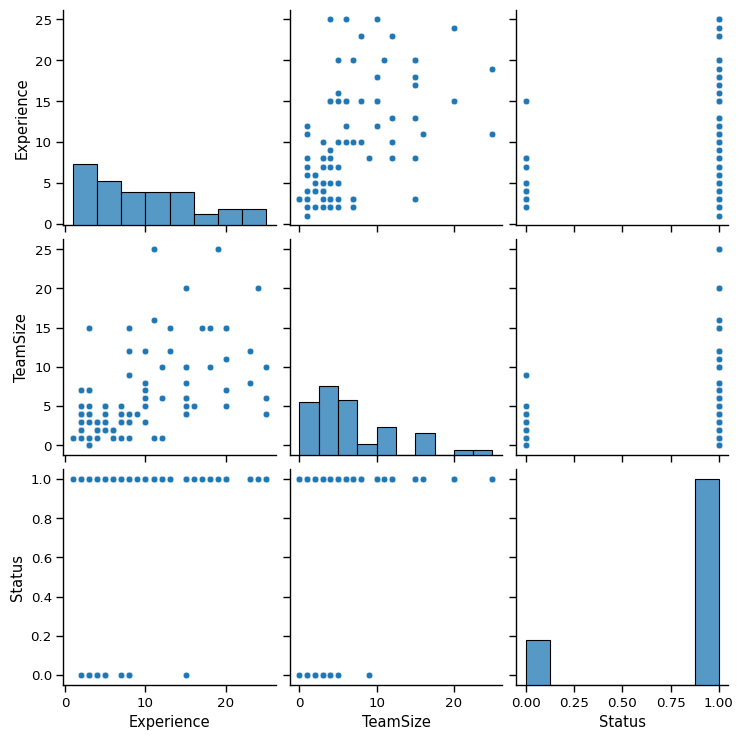

In [228]:
##############################################
display_colored_message("\nPAIR PLOT...")
# Create a pairplot
sns.pairplot(df)

# Display the pairplot
plt.show()

In [229]:
##############################################
display_colored_message("\nLABEL ENCODER...")

display_colored_message("APPLY LABEL ENCODER FOR OBJECT COLUMN TYPE...")


def apply_label_encoder(df) :
  # Filter columns with 'object' dtype
  object_columns = df.select_dtypes(include=['object']).columns

  # Initialize LabelEncoder
  le = LabelEncoder()
  # Apply LabelEncoder to 'object' columns
  for col in object_columns:
    df[col] = le.fit_transform(df[col])
  return df

def apply_one_hot_encoder(df, columns_to_encode=None):


    if columns_to_encode is None:
       columns_to_encode = object_columns
    else:
        # Check if columns_to_encode are in the DataFrame
        columns_to_encode = [col for col in columns_to_encode if col in df.columns]


    columns_to_encode = [col for col in columns_to_encode if col in df.columns]
    print(columns_to_encode)

    if not columns_to_encode:
        raise ValueError("None of the specified columns to encode are in the DataFrame.")

    # Filter columns with 'object' dtype
    object_columns = df.select_dtypes(include=['object']).columns

    # Ensure columns_to_encode are valid object columns
    columns_to_encode = [col for col in columns_to_encode if col in object_columns]

    if not columns_to_encode:
        raise ValueError("None of the columns to encode are of dtype 'object'.")

    # Initialize OneHotEncoder
    ohe = OneHotEncoder(sparse=False, drop=None)  # drop=None to keep all columns

    # Apply OneHotEncoder to 'object' columns
    encoded_data = ohe.fit_transform(df[columns_to_encode])

    # Convert the encoded array back to a DataFrame with proper column names
    encoded_df = pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(columns_to_encode))

    # Drop the original 'object' columns and concatenate the encoded columns
    df = df.drop(columns=columns_to_encode)
    df = pd.concat([df, encoded_df], axis=1)
    return df

# Example usage:

def apply_all_encodings(df) :
    df = apply_one_hot_encoder(df, columns_to_encode=['SkilledStaff'])
    df = apply_label_encoder(df)
    return df

df = apply_all_encodings(df)
print(colored(tabulate(df.head(1), headers='keys', tablefmt='fancy_grid'), 'cyan'))

['SkilledStaff']
╒════╤══════════╤═══════╤══════════════╤═══════════════╤════════════════╤════════════════════════╤══════════════════════╤═══════════════════╤═══════════════╤═════════════════════╤═════════════════╤════════╤══════════════╤══════════════════════╤════════════════════╤═════════════════════════╤════════════╤══════════════════╤════════════╤════════════╤═══════════════╤═══════════════════╤══════════════════════════════╤════════════════╤══════════════════════════╤══════════════════════╤══════════╤══════════════════════╤═════════════════════════╤═════════════════════════╕
│    │   Region │   Job │   Experience │   CompanyType │   ProjectScope │   RequirementClearness │   RequirementChanges │   ProjectPlanning │   ProjectSize │   ProjectManagement │   Communication │   Cost │   Commitment │   ModernTechnologies │   Responsibilities │   OrganizationStability │   Cultural │   TimeDifference │   Progress │   TeamSize │   Methodology │   ProjectSchedule │   ResourceEstimationAccurac

In [230]:
##############################################
#display_colored_message("\n CTGAN model on your dataset...")

#df.to_csv(path + 'risk_processed_dup_prev.csv', index=True)

#model = CTGAN()
#model = CTGAN(epochs=1000, batch_size=32, generator_dim=[128, 128], discriminator_dim=[128, 128])

#model.fit(df)

# Example of post-processing to constrain values
#df['Status'] = df['Status'].clip(lower=0, upper=1)

# Generate new synthetic data
#df = model.sample(len(df) * 2)

#Save the processed data to a new CSV file
#df.to_csv(path + 'risk_processed_gen.csv', index=True)

###
#duplicated_rows(df)
###
#print(colored(tabulate(df.head(3), headers='keys', tablefmt='fancy_grid'), 'cyan'))

In [231]:
##############################################
display_colored_message("SAVE PROCESSED CSV FILE ...")

#Save the processed data to a new CSV file
df.to_csv(path + 'risk_processed.csv', index=True)

In [232]:
##############################################
display_colored_message("MODEL DATA SPLIT..")

# Dropping multiple columns in a single call
columns_to_drop = ['Cost','Region']
#columns_to_drop = ['Cost', 'Region', 'Job', 'OrganizationStability', 'CompanyType', 'Methodology', 'CustomerCommitment']

# Extend ALL_DROPPED_COLUMNS with elements of columns_to_drop if they do not already exist
for column in columns_to_drop:
    if column not in ALL_DROPPED_COLUMNS:
        ALL_DROPPED_COLUMNS.append(column)

df_train = df.copy()
df_train = df_train.drop(columns=columns_to_drop)

print (df_train.shape)
X = df_train
y = df_train.Status

X = X.drop('Status',axis=1) #Remove label

# Example usage:
scaler_type = "STANDARD_SCALER"  # Change to "MINMAX_SCALER" for Min-Max Scaling

#Get the scaler
def get_scaler(scaler_type):
    if scaler_type == "STANDARD_SCALER":
        # Rescale and normalize the features
        # Standardization (Normalization)
        return StandardScaler()
    elif scaler_type == "MINMAX_SCALER":
        # Min-Max Scaling (Rescaling)
        return MinMaxScaler()
    else:
        return None


scaler = get_scaler(scaler_type)

X_scaled = scaler.fit_transform(X)

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(X_scaled,y, test_size = 0.15,
random_state = 42)

print(colored(tabulate(X.head(2), headers='keys', tablefmt='fancy_grid'), 'cyan'))

display_colored_sub_message("\nAFTER Scaler...")

# Convert X_train to a DataFrame
print(colored(tabulate(pd.DataFrame(X_scaled).head(2), headers='keys', tablefmt='fancy_grid'), 'cyan'))

display_colored_sub_message(f"\nTraining data size: {X_train.shape}")
display_colored_sub_message(f"Testing data size: {X_test.shape}")

(90, 28)
╒════╤═══════╤══════════════╤═══════════════╤════════════════╤════════════════════════╤══════════════════════╤═══════════════════╤═══════════════╤═════════════════════╤═════════════════╤══════════════╤══════════════════════╤════════════════════╤═════════════════════════╤════════════╤══════════════════╤════════════╤════════════╤═══════════════╤═══════════════════╤══════════════════════════════╤════════════════╤══════════════════════════╤══════════════════════╤══════════════════════╤═════════════════════════╤═════════════════════════╕
│    │   Job │   Experience │   CompanyType │   ProjectScope │   RequirementClearness │   RequirementChanges │   ProjectPlanning │   ProjectSize │   ProjectManagement │   Communication │   Commitment │   ModernTechnologies │   Responsibilities │   OrganizationStability │   Cultural │   TimeDifference │   Progress │   TeamSize │   Methodology │   ProjectSchedule │   ResourceEstimationAccuracy │   ScopeChanges │   IncompleteRequirements │   CustomerC

LogisticRegression Model
Time taken for training and prediction: 0.008 seconds
Train Accuracy: 1.000
Test Accuracy: 0.929

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      0.92      0.96        13

    accuracy                           0.93        14
   macro avg       0.75      0.96      0.81        14
weighted avg       0.96      0.93      0.94        14

DecisionTree Model
Time taken for training and prediction: 0.002 seconds
Train Accuracy: 1.000
Test Accuracy: 0.714

Classification Report:
              precision    recall  f1-score   support

           0       0.20      1.00      0.33         1
           1       1.00      0.69      0.82        13

    accuracy                           0.71        14
   macro avg       0.60      0.85      0.58        14
weighted avg       0.94      0.71      0.78        14

RandomForest Model
Time taken for training and prediction: 0

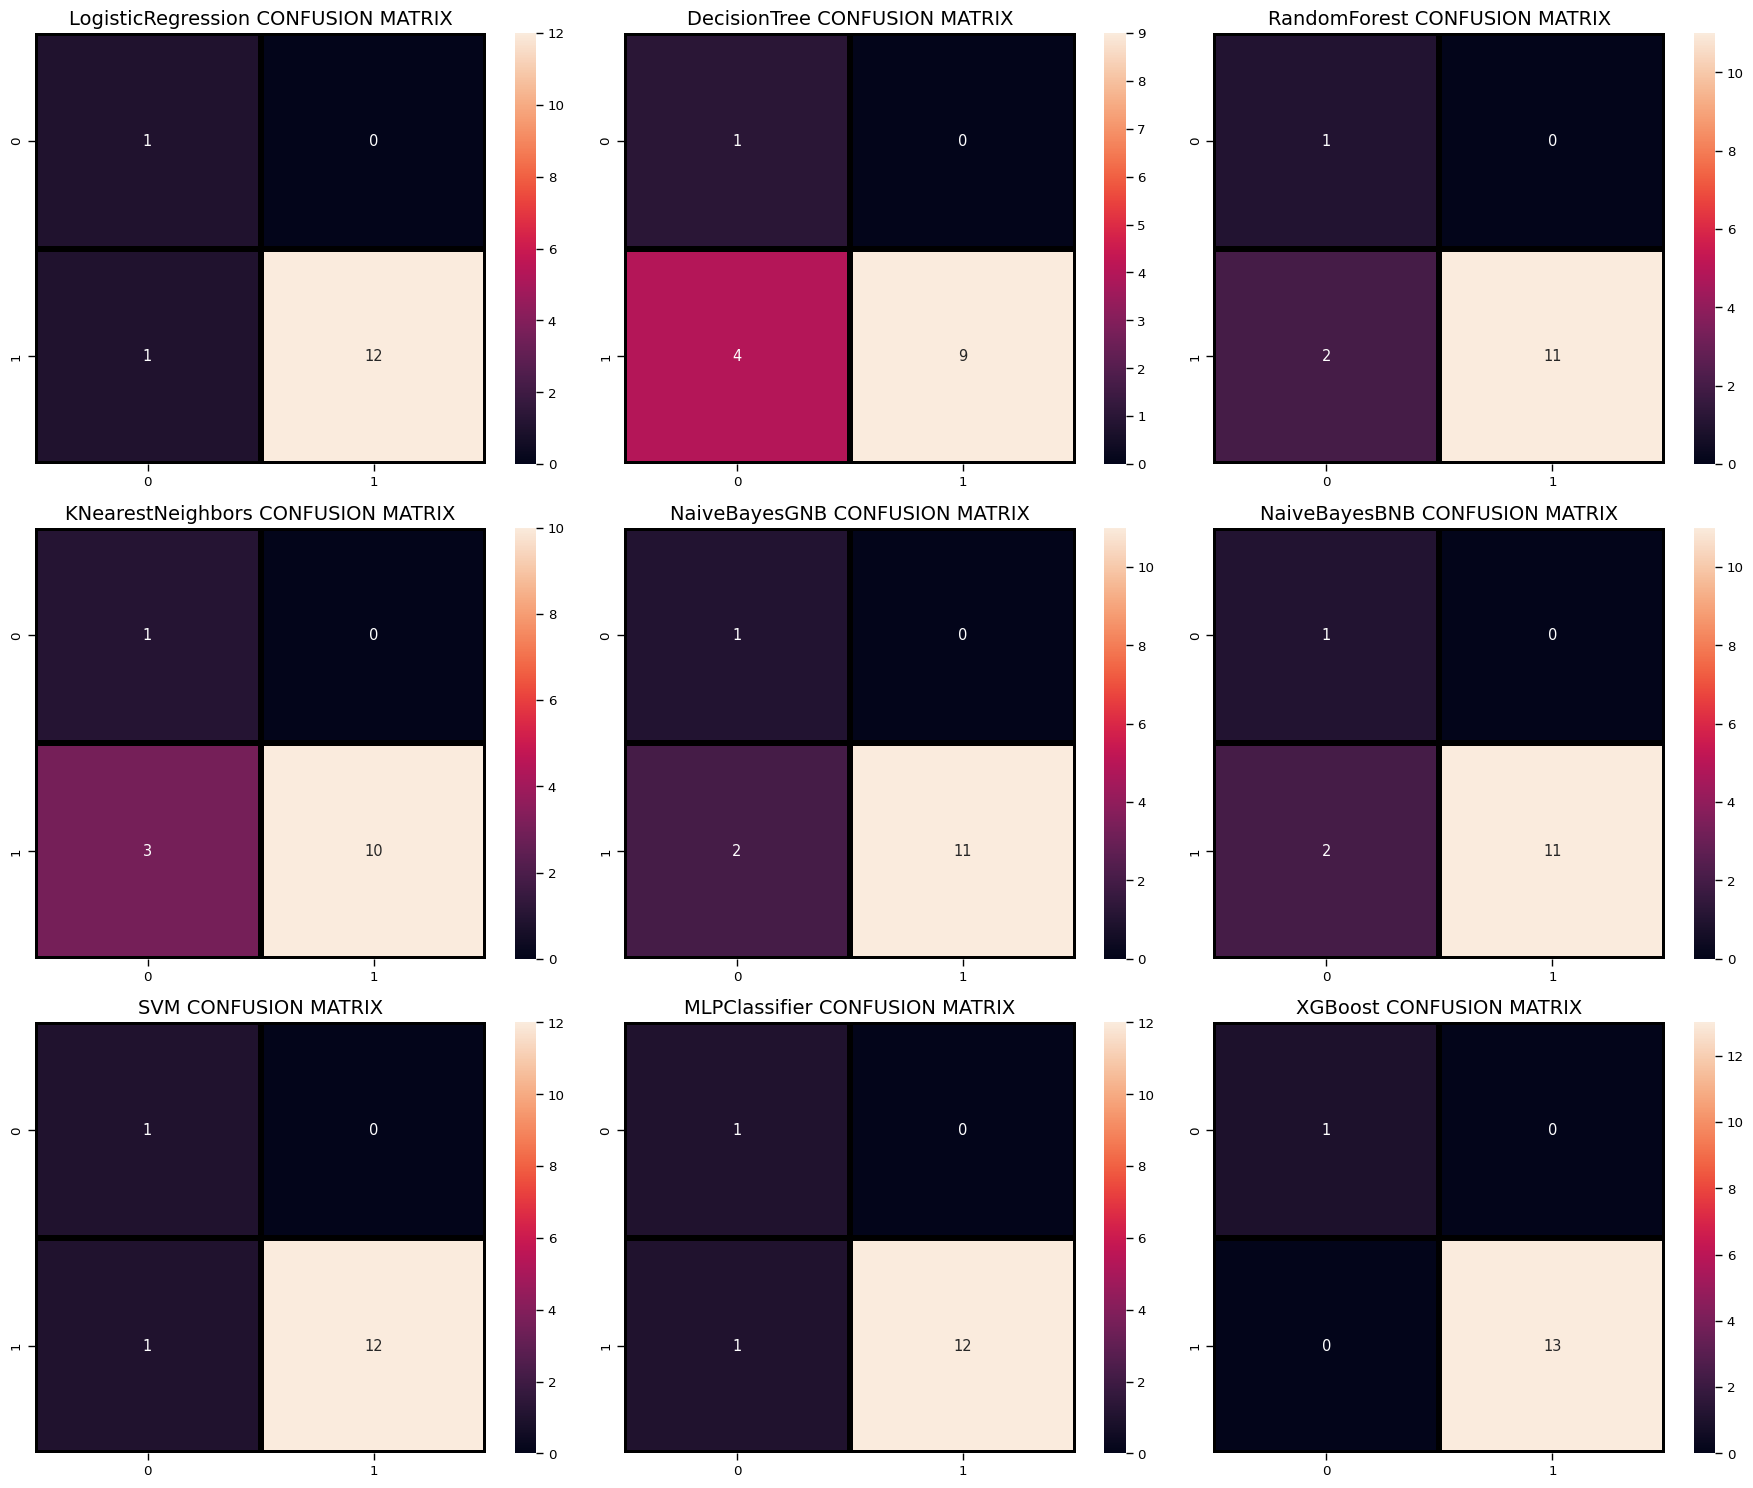

In [233]:
##############################################
display_colored_message("MODELS SCORE AND CONFUSION MATRIX...")

# Apply SMOTE for oversampling on the training data
smote = SMOTE(random_state=42, k_neighbors=3)  # Set k_neighbors to 3
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)

#ros = RandomOverSampler(random_state=42)
#X_train_oversampled, y_train_oversampled = ros.fit_resample(X_train, y_train)

# List of models to train
models = [
   ("LogisticRegression", LogisticRegression(C=1, max_iter=100, solver='newton-cg')),
    ("DecisionTree", DecisionTreeClassifier()),
    ("RandomForest", RandomForestClassifier(n_estimators=150,max_depth=17,
                          min_samples_leaf=10,min_samples_split=9)),
    ("KNearestNeighbors", KNeighborsClassifier(n_neighbors=5)),
    ("NaiveBayesGNB", GaussianNB()),
    ("NaiveBayesBNB", BernoulliNB()),
    ("SVM", SGDClassifier(loss='log_loss', random_state=42, alpha=0.1, max_iter=1000, penalty='l2', tol=0.001)),
    #("SVM", SGDClassifier(alpha=0.01, max_iter=1000, penalty='l2', tol=0.001, loss='log', random_state=42)),
    ("MLPClassifier", MLPClassifier(activation='relu', alpha=0.001, hidden_layer_sizes=(50,), solver='adam')),
    ("XGBoost", XGBClassifier())
]

#New fucntion evaluate_confusionMatric_and_plot_models
def evaluate_confusionMatric_and_plot_models(models, X_train, X_test, y_train, y_test):

    # Create a DataFrame to store the evaluation metrics for each model
    model_metrics = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ExecutionTime'])

    # Function to calculate evaluation metrics and add them to the DataFrame
    def evaluate_model(model, model_name, X_test, y_test, executionTime):

        # Predict labels
        y_pred = model.predict(X_test)

        # Calculate evaluation metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # Add metrics to the DataFrame
        model_metrics.loc[len(model_metrics)] = [model_name, accuracy, precision, recall, f1, executionTime]

    # Train and evaluate models
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.ravel()

    # Train each model and plot confusion matrix
    for i, (name, model) in enumerate(models):

        # Measure start time
        start_time = time.time()

        model.fit(X_train, y_train)
        predicted_y = model.predict(X_test)

        # Measure end time
        end_time = time.time()

        # Calculate elapsed time
        executionTime = end_time - start_time

        scoreTrain = model.score(X_train, y_train)
        scoreTest = model.score(X_test, y_test)

        # Print model header with color
        display_colored_title_message(f'{name} Model')
        print(f"Time taken for training and prediction: {executionTime:.3f} seconds")

        print(colored(f"Train Accuracy: {scoreTrain:.3f}", 'green'))
        print(colored(f"Test Accuracy: {scoreTest:.3f}\n", 'green'))

        # Print classification report with color
        print(colored("Classification Report:", 'blue'))
        report = classification_report(y_test, predicted_y)
        print(colored(report, 'yellow'))

        sns.heatmap(confusion_matrix(y_test, predicted_y), annot=True, fmt="d", linecolor="k", linewidths=3, ax=axes[i])
        axes[i].set_title(f"{name} CONFUSION MATRIX", fontsize=14)

        evaluate_model(model, name, X_test, y_test, executionTime)

    plt.tight_layout()
    plt.show()

    return model_metrics

model_metrics = evaluate_confusionMatric_and_plot_models(models, X_train_oversampled, X_test, y_train_oversampled, y_test)

def add_scaler_model_metrics(scaler, model_metrics):
    scaler_model_metrics = {}
    scaler_model_metrics['scaler'] = scaler
    scaler_model_metrics['model_metrics'] = model_metrics
    return scaler_model_metrics

display_colored_message("MODELS COMPARISON...")

LogisticRegression Model
Time taken for cross-validation and prediction: 0.007 seconds
Cross-Validated Accuracy: 0.967
Cross-Validated Precision: 1.000
Cross-Validated Recall: 0.934
Cross-Validated F1-Score: 0.966

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        61
           1       1.00      0.93      0.97        61

    accuracy                           0.97       122
   macro avg       0.97      0.97      0.97       122
weighted avg       0.97      0.97      0.97       122

DecisionTree Model
Time taken for cross-validation and prediction: 0.002 seconds
Cross-Validated Accuracy: 0.934
Cross-Validated Precision: 0.949
Cross-Validated Recall: 0.918
Cross-Validated F1-Score: 0.933

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94        61
           1       0.95      0.92      0.93        61

    accuracy                           

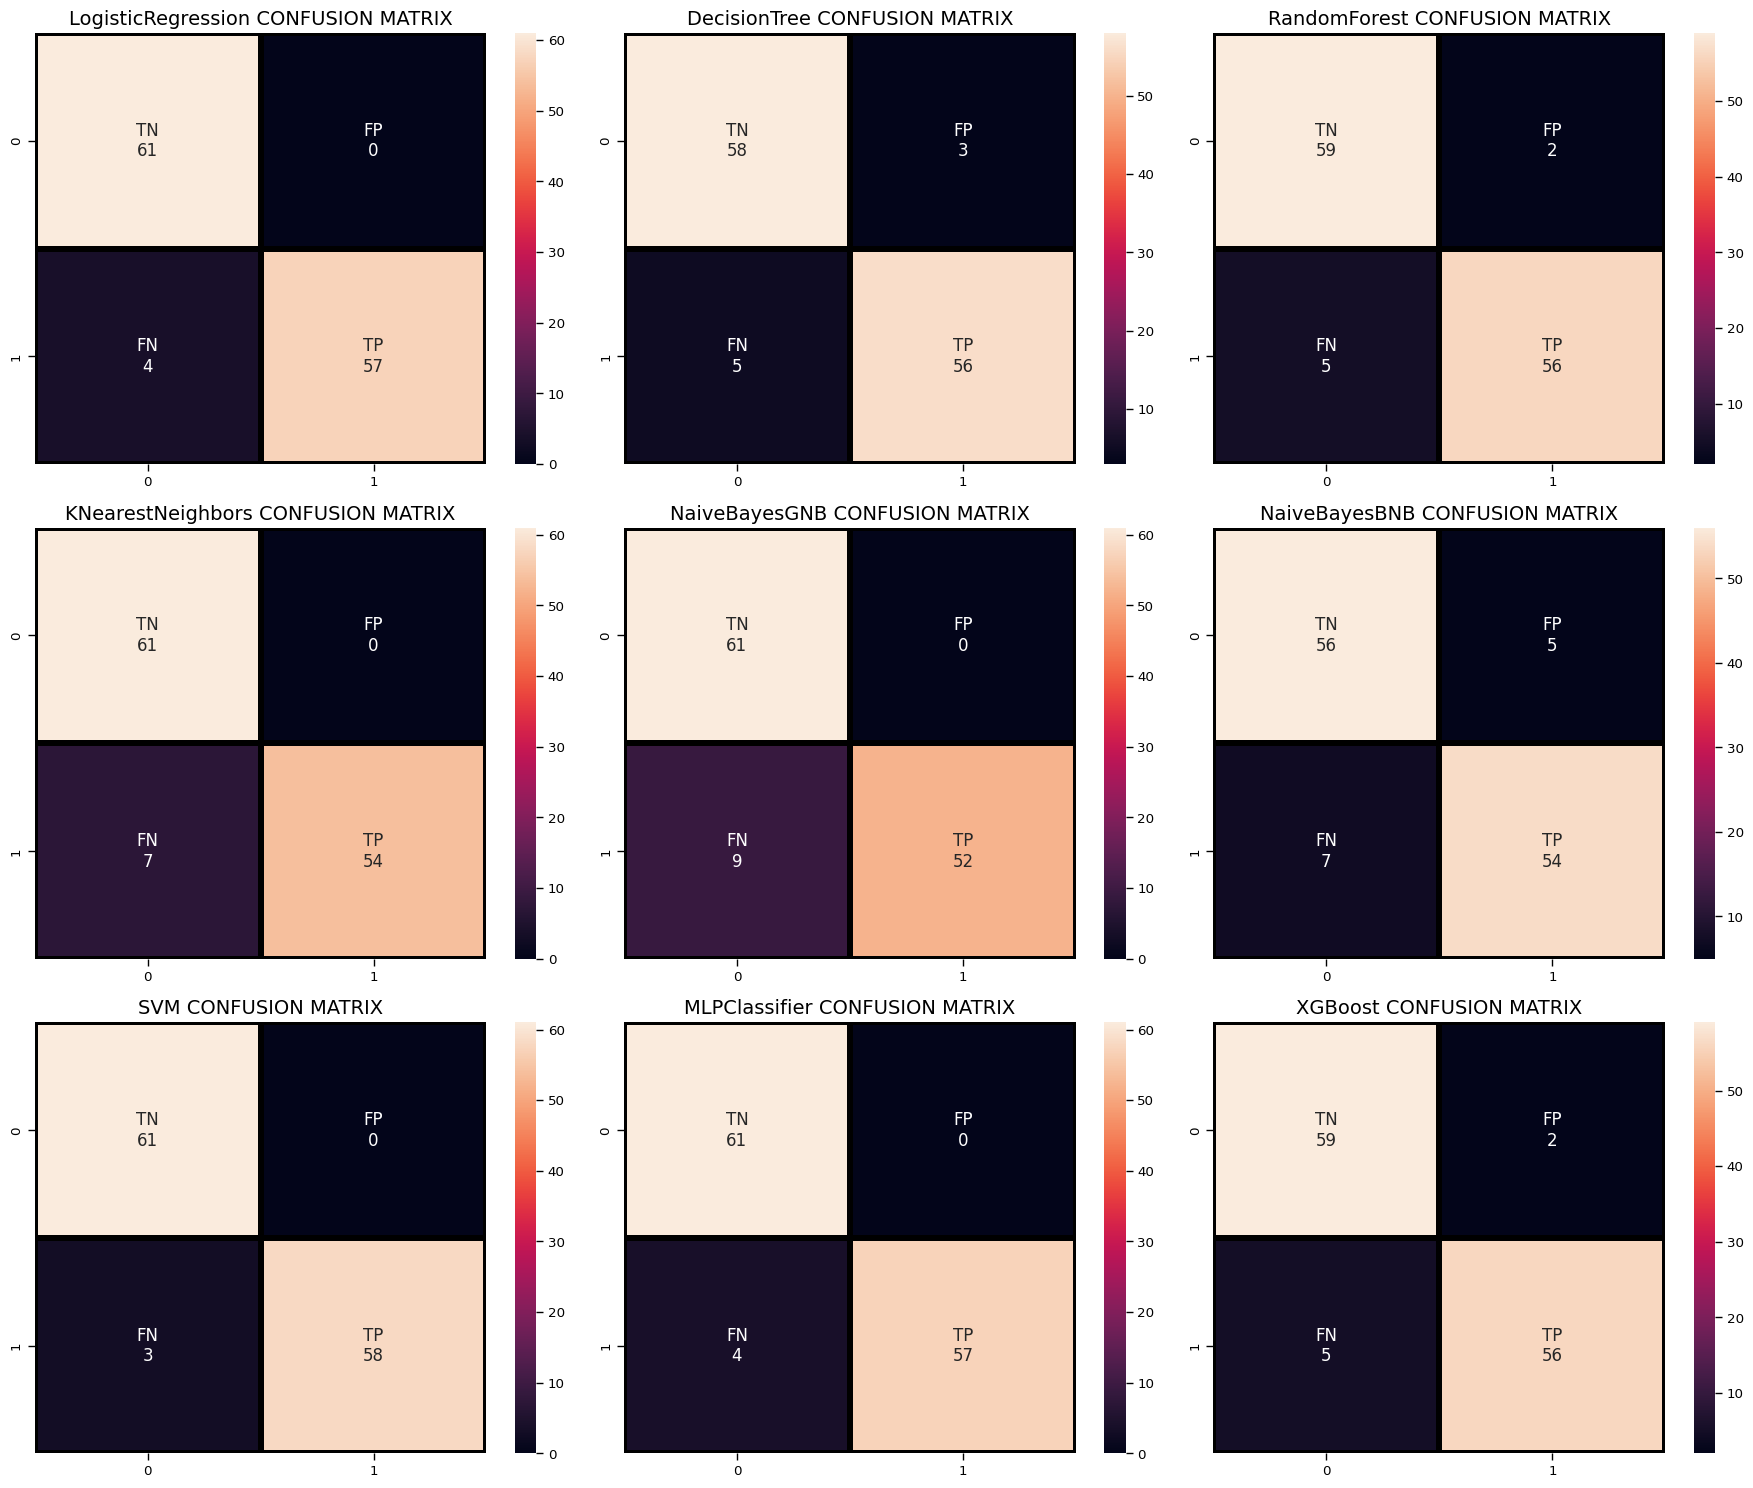

In [234]:
display_colored_message("MODELS SCORE AND CONFUSION MATRIX...")

# Apply SMOTE for oversampling on the training data
smote = SMOTE(random_state=42, k_neighbors=3)  # Set k_neighbors to 3
X_train_oversampled, y_train_oversampled = smote.fit_resample(X_train, y_train)

# Verify the consistency of oversampled data
assert len(X_train_oversampled) == len(y_train_oversampled), \
    f"Length mismatch: {len(X_train_oversampled)} features and {len(y_train_oversampled)} labels."

# List of models to train
models = [
   ("LogisticRegression", LogisticRegression(C=1, max_iter=100, solver='newton-cg')),
    ("DecisionTree", DecisionTreeClassifier()),
    ("RandomForest", RandomForestClassifier(n_estimators=150, max_depth=17, min_samples_leaf=10, min_samples_split=9)),
    ("KNearestNeighbors", KNeighborsClassifier(n_neighbors=5)),
    ("NaiveBayesGNB", GaussianNB()),
    ("NaiveBayesBNB", BernoulliNB()),
    #("SVM", SGDClassifier(loss='log_loss', random_state=42)),
    ("SVM", SGDClassifier(loss='log_loss', random_state=42, alpha=0.1, max_iter=1000, penalty='l2', tol=0.001)),
    ("MLPClassifier", MLPClassifier(activation='relu', alpha=0.001, hidden_layer_sizes=(50,), solver='adam')),
    ("XGBoost", XGBClassifier(learning_rate=0.1, max_depth=3, n_estimators=100, subsample=1.0))
]


# Create a DataFrame to store the evaluation metrics for each model
model_metrics = pd.DataFrame(columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score', 'ExecutionTime'])

# Function to calculate evaluation metrics and add them to the DataFrame
def evaluate_model(model, model_name, X_train, y_train, skf, executionTime):

    # Predict labels using cross-validation
    y_pred = cross_val_predict(model, X_train, y_train, cv=skf)

    # Calculate evaluation metrics
    accuracy = accuracy_score(y_train, y_pred)
    precision = precision_score(y_train, y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train, y_pred)

    # Add metrics to the DataFrame
    model_metrics.loc[len(model_metrics)] = [model_name, accuracy, precision, recall, f1, executionTime]

    print(f"Time taken for cross-validation and prediction: {executionTime:.3f} seconds")
    print(colored(f"Cross-Validated Accuracy: {accuracy:.3f}", 'green'))
    print(colored(f"Cross-Validated Precision: {precision:.3f}", 'green'))
    print(colored(f"Cross-Validated Recall: {recall:.3f}", 'green'))
    print(colored(f"Cross-Validated F1-Score: {f1:.3f}\n", 'green'))

    return y_pred

# Updated function with Stratified K-Fold Cross-Validation
def evaluate_confusionMatric_and_plot_models(models, X_train, y_train):

    # Initialize StratifiedKFold
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Train and evaluate models
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    axes = axes.ravel()

    for i, (name, model) in enumerate(models):

        # Measure start time
        start_time = time.time()

        model.fit(X_train, y_train)

        # Measure end time
        end_time = time.time()

        # Calculate elapsed time
        executionTime = end_time - start_time

        # Print model header with color
        display_colored_title_message(f'{name} Model')

        # Evaluate the model
        y_pred = evaluate_model(model, name, X_train, y_train, skf, executionTime)

        # Print classification report with color
        print(colored("Classification Report:", 'blue'))
        report = classification_report(y_train, y_pred)
        print(colored(report, 'yellow'))

        conf_mat = confusion_matrix(y_train, y_pred)

        # Define labels
        group_names = ['TN', 'FP', 'FN', 'TP']
        group_counts = ["{0:0.0f}".format(value) for value in conf_mat.flatten()]
        labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_names, group_counts)]

        # Convert labels to a 2D list for heatmap annotation
        labels_2d = [
            [labels[0], labels[1]],
            [labels[2], labels[3]]
        ]

        # Plot confusion matrix
        sns.heatmap(conf_mat, annot=labels_2d, annot_kws={"size": 12}, fmt="",  linecolor="k", linewidths=3, ax=axes[i])
        axes[i].set_title(f"{name} CONFUSION MATRIX", fontsize=14)


    plt.tight_layout()
    plt.show()

    return model_metrics

# Evaluate the models with Stratified K-Fold Cross-Validation
model_metrics = evaluate_confusionMatric_and_plot_models(models, X_train_oversampled, y_train_oversampled)

def add_scaler_model_metrics(scaler, model_metrics):
    scaler_model_metrics = {}
    scaler_model_metrics['scaler'] = scaler
    scaler_model_metrics['model_metrics'] = model_metrics
    return scaler_model_metrics

display_colored_message("MODELS COMPARISON...")


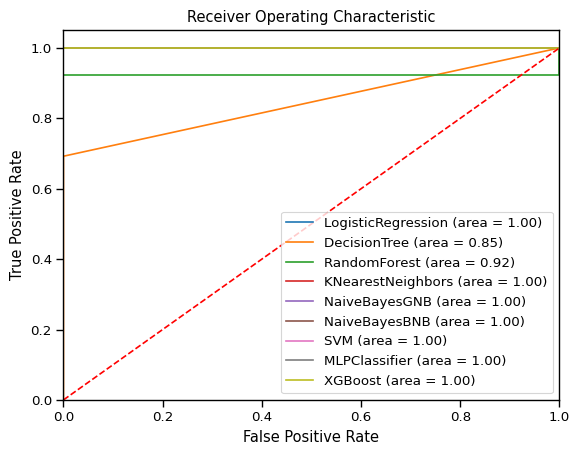

In [235]:
##############################################
display_colored_message("ROC CURVE AND AUC SCORE...")

# New function ROC Curve and AUC Score
def calculate_and_plot_roc(models, X_test, y_test):

    # Define dictionaries to store ROC AUC scores and curves
    roc_auc_scores = {}
    fpr_tpr = {}

    # Calculate ROC AUC scores and curves for each model
    for name, model in models:

      # Predict probabilities for the positive class
        if hasattr(model, "predict_proba"):
            y_pred_proba = model.predict_proba(X_test)[:, 1]
        else:
            y_pred_proba = model.decision_function(X_test)

        roc_auc = roc_auc_score(y_test, y_pred_proba)

        fpr, tpr, p = roc_curve(y_test, y_pred_proba)
        roc_auc_scores[name] = roc_auc
        fpr_tpr[name] = (fpr, tpr)

    # Plot ROC curves
    plt.figure()
    for name in roc_auc_scores:
        fpr, tpr = fpr_tpr[name]
        plt.plot(fpr, tpr, label=f'{name} (area = {roc_auc_scores[name]:.2f})')

    plt.plot([0, 1], [0, 1], 'r--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

calculate_and_plot_roc(models, X_test, y_test)

In [236]:
display_colored_message("MODEL METRICS...")

# New Function to save and display model metrics
def save_and_display_model_metrics(model_metrics):
    # Apply styles to highlight the highest and lowest metric for each model
    def highlight_max_min(s):
        is_max = s == s.max()
        is_min = s == s.min()
        return ['background-color: yellow' if v else 'background-color: red' if u else '' for v, u in zip(is_max, is_min)]

    # Apply the style to the DataFrame
    styled_model_metrics = model_metrics.style.apply(highlight_max_min, subset=['Accuracy', 'Precision', 'Recall', 'F1-score', 'ExecutionTime'])

    # Save the styled DataFrame to an HTML file
    styled_model_metrics_file = "model_metrics.html"
    styled_model_metrics_html = styled_model_metrics.to_html()
    with open(styled_model_metrics_file, "w") as f:
        f.write(styled_model_metrics_html)

    print("Styled model metrics saved to:", styled_model_metrics_file)
    # Display the HTML output
    display(HTML(styled_model_metrics_html))

save_and_display_model_metrics(model_metrics)


Styled model metrics saved to: model_metrics.html


,Model,Accuracy,Precision,Recall,F1-score,ExecutionTime
0,LogisticRegression,0.967213,1.000000,0.934426,0.966102,0.006912
1,DecisionTree,0.934426,0.949153,0.918033,0.933333,0.001605
2,RandomForest,0.942623,0.965517,0.918033,0.941176,0.343399
3,KNearestNeighbors,0.942623,1.000000,0.885246,0.939130,0.001209
4,NaiveBayesGNB,0.926230,1.000000,0.852459,0.920354,0.001979
5,NaiveBayesBNB,0.901639,0.915254,0.885246,0.900000,0.002503
6,SVM,0.975410,1.000000,0.950820,0.974790,0.002949
7,MLPClassifier,0.967213,1.000000,0.934426,0.966102,0.172869
8,XGBoost,0.942623,0.965517,0.918033,0.941176,0.026311


In [237]:
##############################################
display_colored_message("EVALUATION METRICS...")

# Define the models and their corresponding evaluation metrics
models_list = [name for name, model in models]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

# Initialize lists to store the metrics for each model
accuracies = []
precisions = []
recalls = []
f1_scores = []

# Populate the lists with the metrics for each model
for model_name in models_list:
    model_metrics_row = model_metrics[model_metrics['Model'] == model_name].iloc[0]
    accuracies.append(model_metrics_row['Accuracy'])
    precisions.append(model_metrics_row['Precision'])
    recalls.append(model_metrics_row['Recall'])
    f1_scores.append(model_metrics_row['F1-score'])

In [238]:
##############################################
display_colored_message("MODEL PERFORMANCE BY METRICS...")

# Bar plot comparison between metrics for each model
fig = go.Figure()
for model_name in models_list:
  model_index = models_list.index(model_name)
  metrics_values = [accuracies[model_index], precisions[model_index], recalls[model_index], f1_scores[model_index]]
  fig.add_trace(go.Bar(
      x=metrics,
      y=metrics_values,
      name=model_name,
      marker=dict(color=px.colors.qualitative.Plotly[model_index]),
      width=0.08
  ))

fig.update_layout(
  barmode='group',
  title='Model Performance Comparison by Metric',
  xaxis_title='Metrics',
  yaxis_title='Score',
  legend_title='Model',
  width=1400,  # Adjust the width of the plot
  height=500  # Optionally adjust the height of the plot
)
fig.show()

In [239]:
##############################################
display_colored_message("MODEL RADAR CHART COMPARAISON...")

# Radar chart comparison between metrics for each model
fig = go.Figure()
for model_name in models_list:
    model_index = models_list.index(model_name)
    fig.add_trace(go.Scatterpolar(
        r=[accuracies[model_index], precisions[model_index], recalls[model_index], f1_scores[model_index]],
        theta=metrics,
        fill='toself',
        name=model_name,
        marker=dict(color=px.colors.qualitative.Plotly[model_index]),
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1]
        )),
    showlegend=True,
    title='Model Performance Comparison by Metric',
    width=1200,
    height=800,
)
fig.show()

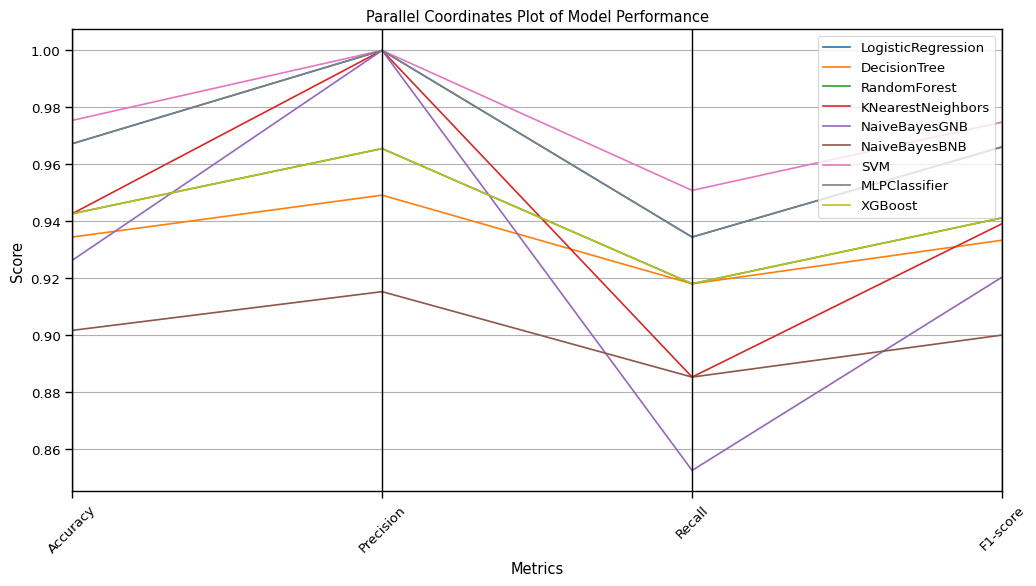

In [240]:
##############################################
display_colored_message("MODEL PERFORMANCE PARALLEL COORDINATES...")

# Parallel coordinates plot for model performance
scores = {'Model': models_list}
for metric in metrics:
    scores[metric] = [model_metrics[model_metrics['Model'] == model_name].iloc[0][metric] for model_name in models_list]

parallel_data = pd.DataFrame(scores)
colors = plt.cm.tab10(range(len(models_list)))


plt.figure(figsize=(12, 6))
parallel_coordinates(parallel_data, 'Model', colormap='viridis', color=colors)
plt.legend(loc='upper right')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.title('Parallel Coordinates Plot of Model Performance')
plt.show()


In [241]:
##############################################
display_colored_message("BEST MODEL Selection...")
def DYNAMIC_SELECTION_BEST_MODEL(model_metrics):
  # Select all models that have the max value in 'Accuracy'
  max_Accuracy_models = model_metrics[model_metrics['Accuracy'] == model_metrics['Accuracy'].max()]

  # From those, select the model(s) that have the max value in 'Precision'
  max_precision_models = max_Accuracy_models[max_Accuracy_models['Precision'] == max_Accuracy_models['Precision'].max()]

  # Calculate the sum of 'Accuracy', 'Precision', 'Recall', and 'F1-score' for each row
  max_precision_models['TOTAL_MODEL_SCORE'] = max_precision_models[['Accuracy', 'Precision', 'Recall', 'F1-score']].sum(axis=1)

  # Get the row with the maximum TOTAL_MODEL_SCORE
  max_total_score_models = max_precision_models[max_precision_models['TOTAL_MODEL_SCORE'] == max_precision_models['TOTAL_MODEL_SCORE'].max()]

  print(max_total_score_models)

  # Among those, select the one with the minimum 'ExecutionTime'
  best_model_row = max_total_score_models.loc[max_total_score_models['ExecutionTime'].idxmin()]

  return best_model_row['Model']

SELECTION_MODEL_TYPE = 'DYNAMIC_SELECTION_MODEL'
#SELECTION_MODEL_TYPE = 'MANUAL_SELECTION_MODEL'

display_colored_title_message(f"SELECTION_MODEL_TYPE : {SELECTION_MODEL_TYPE}...")

if SELECTION_MODEL_TYPE == 'DYNAMIC_SELECTION_MODEL':
  MODEL_SELECTED = DYNAMIC_SELECTION_BEST_MODEL(model_metrics)
else:
  #"LogisticRegression" "DecisionTree" "RandomForest" "KNearestNeighbors" "NaiveBayesGNB" "SVM" "NaiveBayesBNB" "MLPClassifier" "XGBoost"
  MODEL_SELECTED = "MLPClassifier"

display_colored_sub_message(f"TESTING DATASET APPLY MODEL : {MODEL_SELECTED}...")

# Find Best model in the models list
best_model = None
for name, model in models:
    if name == MODEL_SELECTED:
        best_model = model
        break

SELECTION_MODEL_TYPE : DYNAMIC_SELECTION_MODEL...
  Model  Accuracy  Precision   Recall  F1-score  ExecutionTime  \
6   SVM   0.97541        1.0  0.95082   0.97479       0.002949   

   TOTAL_MODEL_SCORE  
6           3.901019  
TESTING DATASET APPLY MODEL : SVM...


In [242]:
##############################################
display_colored_message("BEST MODEL OPTIMIZATIOMN...")

# Define the parameter grid for each model
param_grids = {
    "LogisticRegression": {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['newton-cg', 'lbfgs', 'liblinear'],
        'max_iter': [100, 200, 300]
    },
    "DecisionTree": {
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    "RandomForest": {
        'n_estimators': [100, 150, 200],
        'max_depth': [10, 17, 25, None],
        'min_samples_split': [2, 5, 9],
        'min_samples_leaf': [1, 5, 10]
    },
    "KNearestNeighbors": {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    "NaiveBayesGNB": {},  # No hyperparameters to tune for GaussianNB
    "NaiveBayesBNB": {
        'alpha': [0.1, 1.0, 10.0],
        'binarize': [0.0, 0.5, 1.0]
    },
    "SVM": {
        'alpha': [0.0001, 0.001, 0.01, 0.1],
        'penalty': ['l2', 'l1', 'elasticnet'],
        'max_iter': [1000, 2000, 3000],
        'tol': [1e-3, 1e-4, 1e-5]
    },
    "MLPClassifier": {
        'hidden_layer_sizes': [(50,), (100,), (50, 50)],
        'activation': ['tanh', 'relu'],
        'solver': ['adam', 'sgd'],
        'alpha': [0.0001, 0.001, 0.01]
    },
    "XGBoost": {
        'n_estimators': [100, 150, 200],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.7, 0.8, 1.0]
    }
}

param_grid_best_model = param_grids.get(MODEL_SELECTED)

# Initialize the grid search
grid_search = GridSearchCV(best_model, param_grid_best_model, refit=True, verbose=2, n_jobs=-1)

# Perform the grid search on the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

# Evaluate the model on the test set
best_model_opt = grid_search.best_estimator_
accuracy = best_model_opt.score(X_test, y_test)

# Print model header with color
display_colored_title_message(MODEL_SELECTED)
print(colored(f"Optimized model Accuracy: {accuracy:.4f}", 'green'))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:  {'alpha': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'tol': 0.001}
Best score:  0.8958333333333333
SVM
Optimized model Accuracy: 1.0000


In [243]:
##############################################
display_colored_message("BEST MODEL APPLY CPA...")

rows, columns = df_train.shape

# Assume NB_COMPONENT is defined earlier in your script or function
NB_COMPONENT = columns - 1

# Apply PCA
pca = PCA(n_components=NB_COMPONENT)
principal_components = pca.fit_transform(X_scaled)

# Create column names for the principal components
column_names = [f'PC_{i+1}' for i in range(NB_COMPONENT)]

# Convert the principal components to a DataFrame
principal_df = pd.DataFrame(data=principal_components, columns=column_names)

print("Original Data:")
print(colored(tabulate(df.head(2), headers='keys', tablefmt='fancy_grid'), 'cyan'))

print("\nPrincipal Components:")
print(colored(tabulate(principal_df.head(2), headers='keys', tablefmt='fancy_grid'), 'cyan'))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance_ratio)

# Cumulative explained variance
#cumulative_explained_variance = np.cumsum(explained_variance_ratio)
#print("Cumulative explained variance:", cumulative_explained_variance)

# Create a pipeline with scaler, PCA, and a classifier
pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', PCA(n_components=NB_COMPONENT)),
    ('classifier', best_model)
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Predict using the pipeline
predictions = pipeline.predict(X_test)
print("Predictions:", predictions)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Original Data:
╒════╤══════════╤═══════╤══════════════╤═══════════════╤════════════════╤════════════════════════╤══════════════════════╤═══════════════════╤═══════════════╤═════════════════════╤═════════════════╤════════╤══════════════╤══════════════════════╤════════════════════╤═════════════════════════╤════════════╤══════════════════╤════════════╤════════════╤═══════════════╤═══════════════════╤══════════════════════════════╤════════════════╤══════════════════════════╤══════════════════════╤══════════╤══════════════════════╤═════════════════════════╤═════════════════════════╕
│    │   Region │   Job │   Experience │   CompanyType │   ProjectScope │   RequirementClearness │   RequirementChanges │   ProjectPlanning │   ProjectSize │   ProjectManagement │   Communication │   Cost │   Commitment │   ModernTechnologies │   Responsibilities │   OrganizationStability │   Cultural │   TimeDifference │   Progress │   TeamSize │   Methodology │   ProjectSchedule │   ResourceEstimationAccuracy 

Index(['Timestamp', 'Name', 'Region', 'Job', 'Experience', 'CompanyType',
       'ProjectScope', 'RequirementClearness', 'RequirementChanges',
       'ProjectPlanning', 'ProjectSize', 'ProjectManagement', 'Communication',
       'Cost', 'Commitment', 'ModernTechnologies', 'Responsibilities',
       'SkilledStaff', 'OrganizationStability', 'Cultural', 'TimeDifference',
       'Progress', 'TeamSize', 'Methodology', 'ProjectSchedule',
       'ResourceEstimationAccuracy', 'ScopeChanges', 'IncompleteRequirements',
       'CustomerCommitment'],
      dtype='object')
ORIGINAL TESTING DATASET...
╒════╤═════════════╤════════╤═════════════╤══════════════════════╤══════════════╤═══════════════╤════════════════╤════════════════════════╤══════════════════════╤═══════════════════╤═══════════════╤═════════════════════╤═════════════════╤══════════╤══════════════╤══════════════════════╤════════════════════╤════════════════╤═════════════════════════╤════════════════╤══════════════════╤════════════════╤═

╒════╤═════════════╤════════╤═════════════╤══════════════════════╤══════════════╤════════════════╤═════════════════╤═════════════════════════╤═══════════════════════╤════════════════════╤════════════════╤══════════════════════╤═════════════════╤══════════╤══════════════╤═══════════════════════╤════════════════════╤═════════════════╤══════════════════════════╤════════════════╤═══════════════════╤════════════════╤═════════════╤═══════════════════╤════════════════════╤════════════════════════════════╤═════════════════╤═══════════════════════════╤═══════════════════════╤══════════╕
│    │ Timestamp   │ Name   │ Region      │ Job                  │   Experience │ Company Type   │ Project Scope   │ Requirement Clearness   │ Requirement Changes   │ Project Planning   │ Project Size   │ Project Management   │ Communication   │ Cost     │ Commitment   │ Modern Technologies   │ Responsibilities   │ Skilled Staff   │ Organization Stability   │ Cultural       │ Time Difference   │ Progress       │

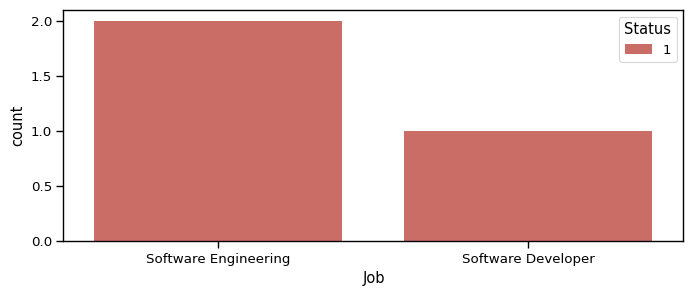

In [244]:
##############################################
display_colored_message("MODEL PREDICTION...")

# Given DataFrame
testingData = pd.DataFrame({
    'Timestamp': ['2024/08/04', '2024/07/10', '2024/5/13'],
    'Name': ['ID1', 'ID1', 'ID3'],
    'Region': ['Middle East', 'Middle East', 'Middle East'],
    'Job': ['Software Engineering', 'Software Engineering', 'Software Developer'],
    'Experience': ['8', '8', '4'],
    'Company Type': ['International', 'International', 'National'],
    'Project Scope': ['Unclear', 'Unclear', 'Clear'],
    'Requirement Clearness': ['Moderate', 'Unclear', 'Clear'],
    'Requirement Changes': ['Minor', 'Normal', 'Normal'],
    'Project Planning': ['Ambiguous', 'Ambiguous', 'Ambiguous'],
    'Project Size': ['Large', 'Medium', 'Medium'],
    'Project Management': ['Moderate', 'Moderate', 'Expert'],
    'Communication': ['Worst', 'Moderate', 'Moderate'],
    'Cost': ['Moderate', 'Balanced', 'Moderate'],
    'Commitment': ['Low', 'Moderate', 'Moderate'],
    'Modern Technologies': ['Many', 'Many', 'Normal'],
    'Responsibilities': ['Unclear', 'Unclear', 'Clear'],
    'Skilled Staff': ['Disagree', 'Agree', 'Moderate'],
    'Organization Stability': ['Normal', 'Normal', 'Stable'],
    'Cultural': ['Reasonable', 'Can be handled', 'Reasonable'],
    'Time Difference': ['Can be handled', 'Can be handled', 'Reasonable'],
    'Progress': ['Delivery level', 'Sprint level', 'Task level'],
    'Team Size': ['9', '8', '4'],
    'Methodology': ['Scrum', 'Kanban', 'Rapid development'],
    'Project Schedule': ['Highly unrealistic', 'Highly unrealistic', 'Highly unrealistic'],
    'Resource Estimation Accuracy': ['Not accurate at all', 'Not accurate at all', 'Very accurate'],
    'Scope Changes': ['Minor changes', 'Minor changes', 'Minor changes'],
    'Incomplete Requirements': ['Partially incomplete', 'Partially incomplete', 'Partially incomplete'],
    'Customer Commitment': ['Moderate', 'Moderate', 'Strong']

})


path = '/content/sample_data/'
#testingData = pd.read_csv(path + 'risk_test.csv')

testDf = testingData.copy()

display_colored_message("RENAME COLUMNS...")

#RENAME COLUMNS
testDf = rename_columns(testDf)
print(testDf.columns)

display_colored_sub_message("ORIGINAL TESTING DATASET...")

print(colored(tabulate(testDf.head(3), headers='keys', tablefmt='fancy_grid'), 'cyan'))

#REMOVE SAME COLUMNS
print(ALL_DROPPED_COLUMNS)

#FILL MISSING VALUES
data_prep_fill_mising_values(testDf)

#DROP SAME COLUMNS
testDf.drop(ALL_DROPPED_COLUMNS, axis=1, inplace=True)

display_colored_sub_message("TESTING DATASET NO MISSING  & DROP COLUMNS...")
print(colored(tabulate(testDf.head(3), headers='keys', tablefmt='fancy_grid'), 'cyan'))

#APPLY encoding
testDf = apply_all_encodings(testDf)

#df_train = df_train.drop(columns=['Status'])

display_colored_sub_message("TESTING DATASET LAPPLY LABEL ENCODER...")
print(colored(tabulate(testDf.head(3), headers='keys', tablefmt='fancy_grid'), 'cyan'))

# Fit and transform the data
scaled_team_data = scaler.transform(testDf)

display_colored_sub_message("TESTING DATASET APPLY SCALER...")
# Convert X_train to a DataFrame
print(colored(tabulate(pd.DataFrame(scaled_team_data).head(3), headers='keys', tablefmt='fancy_grid'), 'cyan'))


# Check if best_model model is found
if best_model is not None:
    # Assuming you have your data for prediction stored in X_pred
    # Make predictions using best_model model
    predictions = best_model.predict(scaled_team_data)
    # Now you have predictions using best_model model
    print(f"{MODEL_SELECTED} prediction:", predictions)

    # Define a mapping dictionary
    #mapping = {1: 'Y', 0: 'N'}

    # Assuming predictions is a NumPy array or a Pandas Series
    predictions_categorical = ['1' if pred == 1 else '0' for pred in predictions]

    testingData['Status'] = predictions_categorical
else:
    print(f"{MODEL_SELECTED} model not found in the models list.")

display_colored_message(f"TESTING DATASET WITH PREDICTION...")
print(colored(tabulate(testingData.head(3), headers='keys', tablefmt='fancy_grid'), 'cyan'))

testOutputFileName = path + 'risk_test_output.csv'
display_colored_sub_message(f"GENERATE THE NEW DATASET WITH PREDICTION {testOutputFileName}")
# Assuming df is your DataFrame
testingData.to_csv(testOutputFileName, index=False)

display_colored_message("DATA VISULAZATION...")

# Counting the accurance of each value in Job column
testingData['Job'].value_counts()

# comparing Project status with Job column
plt.figure(figsize=(8,3))
sns.countplot(x = 'Job',hue ='Status', data=testingData , palette='hls')
plt.show()

In [245]:
####################################################
display_colored_message("DEEP LEARNING...")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# Enhanced deep learning model
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1], activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.001)

model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Accuracy: {accuracy*100:.2f}%')

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
y_pred = model.predict(X_test).flatten()
roc_auc = roc_auc_score(y_test, y_pred)

print(f'Deep Learning Model Accuracy: {accuracy * 100:.2f}%')
print(f'Deep Learning Model AUC-ROC: {roc_auc:.2f}')

predictions = model.predict(scaled_team_data).flatten()

threshold = 0.5

predictions_proba = model.predict(scaled_team_data).flatten()
predictions = (predictions_proba > threshold).astype(int)

print(f"prediction probabilities:", predictions_proba)
print(f"Sequential Model binary predictions:", predictions)





Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 256ms/step - accuracy: 0.5542 - loss: 0.9045 - val_accuracy: 0.5625 - val_loss: 0.6587
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5104 - loss: 1.1449 - val_accuracy: 0.5625 - val_loss: 0.6656
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4236 - loss: 1.2134 - val_accuracy: 0.5625 - val_loss: 0.6695
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5965 - loss: 0.8812 - val_accuracy: 0.5625 - val_loss: 0.6697
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5007 - loss: 0.9586 - val_accuracy: 0.5625 - val_loss: 0.6685
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5757 - loss: 0.7927 - val_accuracy: 0.5000 - val_loss: 0.6684
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5007 - loss: 0.8960 - val_accuracy: 0.5000 - val_loss: 0.6695
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6083 - loss: 0.7082 - val_accuracy: 0.5000 - val_loss: 0.6709